# Yield Curve Construction and Analysis - Canadian Government Bonds


### Core Theory and Equations



#### 1. Dirty Price Calculation

- The **dirty price** is the clean price plus accrued interest since the last coupon payment.


  $$
  \text{Dirty Price} = \text{Clean Price} + \left( \frac{\text{Days Since Last Coupon}}{365} \right) \times \text{Annual Coupon Payment}
  $$



#### 2. Yield to Maturity (YTM) Calculation

- The Yield to Maturity (YTM) is the discount rate ( r ) that equates the present value of all future cash flows (coupons and principal) to the dirty price

- **General Bond Pricing Equation**:
  $$
  \text{Dirty Price} = \sum_{i=1}^{n-1} \frac{C}{(1+r)^{t_i}} + \frac{C+F}{(1+r)^{t_n}}
  $$
  where:
  - \( C \) = coupon payment
  - \( F \) = face value
  - \( t_i \) = actual days to each payment divided by 365

  - Numerical method (Newton's method) used to solve for r 




#### 3. Forward Rates from Spot Rates

- The forward rate from time ( t ) to time \( t+n \) is computed from spot rates.


  $$
  F_{t,t+n} = \left( \frac{(1+S_{t+n})^{t+n}}{(1+S_t)^t} \right)^{\frac{1}{n}} - 1
  $$




#### 4. Covariance Matrices of Log Returns

- Calculate the daily log returns of yields and forward rates, then compute their covariance matrices.

- **Log-return formula**:
  $$
  \text{log-return} = \log\left( \frac{r_{i,j+1}}{r_{i,j}} \right)
  $$

- Covariance matrices computed separately for yield curves and forward curves.



#### 5. Principal Component Analysis (PCA)

- PCA identifies the main directions (eigenvectors) of variation in the yield and forward curves 
- First principal component typically explains the largest amount of variance 
- PCA applied on both yield and forward covariance matrices 


#### Remarks

- Time convention: actual/365 days
- Rates use discrete compounding (not continuous)






---

## Data Collected 

---

In [2]:
# # Updated bond prices with additional columns for the newly uploaded data

# import pandas as pd

# df1 = [

#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/22/2025", "Close": 98.1900, "Open": 98.1800, "High": 98.1900, "Low": 98.1800, "Volume": 40000, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026 ", "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/21/2025", "Close": 98.2500, "Open": 98.2000, "High": 98.2600, "Low": 98.2000, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026 ", "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/20/2025", "Close": 98.2000, "Open": 98.1600, "High": 98.2000, "Low": 98.1600, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026 ", "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/17/2025", "Close": 98.1700, "Open": 98.1100, "High": 98.1700, "Low": 98.1100, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026", "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/16/2025", "Close": 98.1100, "Open": 98.0300, "High": 98.1200, "Low": 98.0300, "Volume": 5000, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/15/2025", "Close": 97.9700, "Open": 97.8000, "High": 97.9700, "Low": 97.8000, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/14/2025", "Close": 97.8600, "Open": 97.8600, "High": 97.8600, "Low": 97.8600, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/13/2025", "Close": 97.9200, "Open": 97.9600, "High": 97.9600, "Low": 97.9200, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/10/2025", "Close": 97.9900, "Open": 98.1300, "High": 98.1300, "Low": 97.9900, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/9/2025", "Close": 98.1500, "Open": 98.1300, "High": 98.1500, "Low": 98.1300, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/8/2025", "Close": 98.1500, "Open": 98.1500, "High": 98.1500, "Low": 98.1500, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/7/2025", "Close": 98.1300, "Open": 98.1700, "High": 98.1700, "Low": 98.1300, "Volume": 4000, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026"   , "Coupon Payment Date":" 6/1/2025"},
#     {"ISIN": "CA135087E679", "Issue Date": "7/21/2015", "Maturity Date": "6/1/2026", "Date": "1/6/2025", "Close": 98.1500, "Open": 98.1500, "High": 98.1500, "Low": 98.1500, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 12/1/2015 " , "Final Coupon Date": "  5/31/2026  " , "Coupon Payment Date":" 6/1/2025 "}
# ]


# df2 = [
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/22/2025", "Close": 99.7000, "Open": 99.7000, "High": 99.7000, "Low": 99.7000, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/21/2025", "Close": 99.7000, "Open": 99.6900, "High": 99.7000, "Low": 99.6900, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/20/2025", "Close": 99.7000, "Open": 99.6800, "High": 99.7000, "Low": 99.6800, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/17/2025", "Close": 99.7000, "Open": 99.6700, "High": 99.7000, "Low": 99.6700, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/16/2025", "Close": 99.6700, "Open": 99.6500, "High": 99.6700, "Low": 99.6500, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/15/2025", "Close": 99.6600, "Open": 99.6200, "High": 99.6600, "Low": 99.6200, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/14/2025", "Close": 99.6400, "Open": 99.6100, "High": 99.6400, "Low": 99.6100, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/13/2025", "Close": 99.6400, "Open": 99.6200, "High": 99.6200, "Low": 99.6200, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/10/2025", "Close": 99.6400, "Open": 99.6300, "High": 99.6400, "Low": 99.6300, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/9/2025", "Close": 99.6300, "Open": 99.6200, "High": 99.6300, "Low": 99.6200, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/8/2025", "Close": 99.6300, "Open": 99.6200, "High": 99.6300, "Low": 99.6200, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/7/2025", "Close": 99.6300, "Open": 99.6200, "High": 99.6300, "Low": 99.6200, "Volume": 0, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
#     {"ISIN": "CA135087N340", "Issue Date": "1/24/2022", "Maturity Date": "4/1/2025", "Date": "1/6/2025", "Close": 99.6400, "Open": 99.6200, "High": 99.6400, "Low": 99.6200, "Volume": 6000, "Coupon Rate (%)": 1.5 , "Coupon Start Date": " 4/1/2022 " , "Final Coupon Date": "  3/31/2025 " , "Coupon Payment Date":" 4/1/2025 "},
# ]




# df3 = [
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/22/2025", "Close": 111.4800, "Open": 111.4700, "High": 111.4800, "Low": 111.4700, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/21/2025", "Close": 111.6100, "Open": 111.5000, "High": 111.6100, "Low": 111.5000, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/20/2025", "Close": 111.5400, "Open": 111.4200, "High": 111.5400, "Low": 111.4200, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/17/2025", "Close": 111.5200, "Open": 111.4000, "High": 111.5200, "Low": 111.4000, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/16/2025", "Close": 111.5100, "Open": 111.2600, "High": 111.5100, "Low": 111.2600, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/15/2025", "Close": 111.4100, "Open": 111.1000, "High": 111.4100, "Low": 111.1000, "Volume": 10000, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/14/2025", "Close": 111.3300, "Open": 111.1300, "High": 111.3300, "Low": 111.1300, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/13/2025", "Close": 111.3300, "Open": 111.3400, "High": 111.3400, "Low": 111.3300, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/10/2025", "Close": 111.4800, "Open": 111.6800, "High": 111.6800, "Low": 111.4800, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/9/2025", "Close": 111.7600, "Open": 111.6000, "High": 111.7600, "Low": 111.6000, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},

#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/8/2025", "Close": 111.7600, "Open": 111.7600, "High": 111.7600, "Low": 111.7600, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/7/2025", "Close": 111.8500, "Open": 111.8500, "High": 111.8500, "Low": 111.8500, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
#     {"ISIN": "CA135087W717", "Issue Date": "5/1/1996", "Maturity Date": "6/1/2027", "Date": "1/6/2025", "Close": 111.8000, "Open": 111.7100, "High": 111.8000, "Low": 111.7100, "Volume": 0, "Coupon Rate (%)": 8.0 , "Coupon Start Date": "  6/1/1996  " , "Final Coupon Date": "  5/31/2027   " , "Coupon Payment Date":"   6/1/2025 "},
# ]

# df4 = [
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/22/2025", "Close": 101.2400, "Open": 101.2400, "High": 101.2400, "Low": 101.2400, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/21/2025", "Close": 101.3900, "Open": 101.2600, "High": 101.3900, "Low": 101.2600, "Volume": 1000, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/20/2025", "Close": 101.2800, "Open": 101.2400, "High": 101.2800, "Low": 101.2400, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/17/2025", "Close": 101.2400, "Open": 101.2000, "High": 101.2400, "Low": 101.2000, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/16/2025", "Close": 101.2200, "Open": 101.1300, "High": 101.2200, "Low": 101.1300, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/15/2025", "Close": 101.0900, "Open": 100.9800, "High": 101.0900, "Low": 100.9800, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/14/2025", "Close": 100.9900, "Open": 100.9900, "High": 100.9900, "Low": 100.9900, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/13/2025", "Close": 101.0900, "Open": 101.0900, "High": 101.0900, "Low": 101.0900, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/10/2025", "Close": 101.2200, "Open": 101.2500, "High": 101.2500, "Low": 101.2200, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/9/2025", "Close": 101.2800, "Open": 101.2500, "High": 101.2800, "Low": 101.2500, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/8/2025", "Close": 101.2700, "Open": 101.2700, "High": 101.2700, "Low": 101.2700, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/7/2025", "Close": 101.3100, "Open": 101.3100, "High": 101.3100, "Low": 101.3100, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
#     {"ISIN":" CA135087R556 ", "Issue Date": "2/12/2024", "Maturity Date": "5/1/2026", "Date": "1/6/2025", "Close": 101.2800, "Open": 101.2600, "High": 101.2800, "Low": 101.2600, "Volume": 0, "Coupon Rate (%)": 4.0, "Coupon Start Date": "5/1/2024", "Final Coupon Date": "4/30/2026", "Coupon Payment Date": "5/1/2025"},
# ]




# df6 = [


#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/22/2025", "Close": 100.0000, "Open": 99.9900, "High": 100.0000, "Low": 99.9900, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/21/2025", "Close": 99.9900, "Open": 99.9900, "High": 99.9900, "Low": 99.9900, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/20/2025", "Close": 100.0100, "Open": 100.0200, "High": 100.0200, "Low": 100.0100, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/17/2025", "Close": 100.0000, "Open": 100.0000, "High": 100.0000, "Low": 100.0000, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/16/2025", "Close": 100.0000, "Open": 100.0000, "High": 100.0000, "Low": 100.0000, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "}, 
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/15/2025", "Close": 100.0200, "Open": 99.9900, "High": 100.0200, "Low": 99.9900, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/14/2025", "Close": 100.0100, "Open": 99.9900, "High": 100.0200, "Low": 99.9900, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},


#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/13/2025", "Close": 100.0200, "Open": 99.9900, "High": 100.0200, "Low": 99.9900, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/10/2025", "Close": 100.0000, "Open": 100.0000, "High": 100.0000, "Low": 100.0000, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/9/2025", "Close": 100.0200, "Open": 100.0000, "High": 100.0300, "Low": 100.0000, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/8/2025", "Close": 100.0300, "Open": 100.0000, "High": 100.0300, "Low": 100.0000, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/7/2025", "Close": 100.0100, "Open": 100.0100, "High": 100.0100, "Low": 100.0100, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
#     {"ISIN":"CA135087P659", "Issue Date": "  11/2/2022  ", "Maturity Date": "  2/1/2025 ","Date": "1/6/2025", "Close": 100.0300, "Open": 100.0100, "High": 100.0300, "Low": 100.0100, "Volume": 0, "Coupon Rate (%)": 3.75, "Coupon Start Date": " 2/1/2023 ", "Final Coupon Date": " 1/31/2025 ", "Coupon Payment Date":" 2/1/2025 "},
# ]





# df7 = [

#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/22/2025", "Close": 96.6900, "Open": 96.6700, "High": 96.6900, "Low": 96.6700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/21/2025", "Close": 96.7500, "Open": 96.6700, "High": 96.7700, "Low": 96.6700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/20/2025", "Close": 96.6900, "Open": 96.6600, "High": 96.6900, "Low": 96.6600, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/17/2025", "Close": 96.6400, "Open": 96.5900, "High": 96.6500, "Low": 96.5900, "Volume": 1000, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/16/2025", "Close": 96.6000, "Open": 96.4400, "High": 96.6000, "Low": 96.4400, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/15/2025", "Close": 96.3600, "Open": 96.1900, "High": 96.3600, "Low": 96.1900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/14/2025", "Close": 96.1900, "Open": 96.1900, "High": 96.1900, "Low": 96.1900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/13/2025", "Close": 96.2800, "Open": 96.3500, "High": 96.3500, "Low": 96.2800, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/10/2025", "Close": 96.3900, "Open": 96.5800, "High": 96.5800, "Low": 96.3900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/9/2025", "Close": 96.6300, "Open": 96.5800, "High": 96.6300, "Low": 96.5800, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/8/2025", "Close": 96.5800, "Open": 96.5900, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/7/2025", "Close": 96.5800, "Open": 96.5800, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/6/2025", "Close": 96.5800, "Open": 96.5800, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"}
# ]




# df5 = [
#     {"ISIN":" CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ",  "Date": "1/22/2025", "Close": 98.5100, "Open": 98.5000, "High": 98.5100, "Low": 98.5000, "Volume": 16000 , "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN":" CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ",  "Date": "1/21/2025", "Close": 98.5500, "Open": 98.5200, "High": 98.5500, "Low": 98.5200, "Volume": 0 , "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/20/2025", "Close": 98.5300, "Open": 98.5000, "High": 98.5300, "Low": 98.5000, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/17/2025", "Close": 98.5000, "Open": 98.4600, "High": 98.5000, "Low": 98.4600, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/16/2025", "Close": 98.4700, "Open": 98.4200, "High": 98.4700, "Low": 98.4200, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/15/2025", "Close": 98.4000, "Open": 98.3400, "High": 98.4000, "Low": 98.3400, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/14/2025", "Close": 98.3600, "Open": 98.3300, "High": 98.3600, "Low": 98.3300, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/13/2025", "Close": 98.3600, "Open": 98.3600, "High": 98.3600, "Low": 98.3400, "Volume": 4000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},


#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/10/2025", "Close": 98.3700, "Open": 98.4100, "High": 98.4200, "Low": 98.3700, "Volume": 27000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/9/2025", "Close": 98.4200, "Open": 98.4000, "High": 98.4200, "Low": 98.4000, "Volume": 8000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/8/2025", "Close": 98.4000, "Open": 98.4000, "High": 98.4000, "Low": 98.4000, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/7/2025", "Close": 98.4100, "Open": 98.4100, "High": 98.4100, "Low": 98.4100, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/6/2025", "Close": 98.4000, "Open": 98.3900, "High": 98.4000, "Low": 98.3900, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
# ]

# df__8_24_2027 = [
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/20/2025", "Close": 101.0500, "Open": 100.7500, "High": 101.0500, "Low": 100.7500, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/17/2025", "Close": 101.0000, "Open": 100.9500, "High": 101.0000, "Low": 100.9500, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/16/2025", "Close": 100.7300, "Open": 100.5500, "High": 100.7300, "Low": 100.5500, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/15/2025", "Close": 100.6700, "Open": 100.4600, "High": 100.6700, "Low": 100.4600, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},

#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/14/2025", "Close": 100.4600, "Open": 100.4600, "High": 100.4600, "Low": 100.4600, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/13/2025", "Close": 100.4100, "Open": 100.4100, "High": 100.4100, "Low": 100.4100, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/10/2025", "Close": 100.7200, "Open": 100.7500, "High": 100.7500, "Low": 100.7200, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/9/2025", "Close": 101.0200, "Open": 100.9700, "High": 101.0200, "Low": 100.9700, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/8/2025", "Close": 100.9400, "Open": 100.9800, "High": 100.9800, "Low": 100.9400, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/7/2025", "Close": 101.0400, "Open": 101.0500, "High": 101.0500, "Low": 101.0400, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"},
#     {"ISIN": "CA135087P733", "Issue Date": "12/2/2022", "Maturity Date": "8/24/2027", "Date": "1/6/2025", "Close": 101.0200, "Open": 101.0200, "High": 101.0200, "Low": 101.0200, "Volume": 0, "Coupon Rate (%)": 3.245, "Coupon Start Date": "2/24/2023", "Final Coupon Date": "8/23/2027", "Coupon Payment Date": "2/24/2025"}
# ]



# #_____________________________________________________________________PROJECT DATA 


# df__3_1_2025 = [ #CAN 1.25 Mar 1
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/20/2025", "Close": 99.8000, "Open": 99.8000, "High": 99.8000, "Low": 99.8000, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/17/2025", "Close": 99.8000, "Open": 99.7600, "High": 99.8000, "Low": 99.7600, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1" , "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/16/2025", "Close": 99.7800, "Open": 99.7500, "High": 99.7800, "Low": 99.7500, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/15/2025", "Close": 99.7700, "Open": 99.7300, "High": 99.7700, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/14/2025", "Close": 99.7300, "Open": 99.7300, "High": 99.7300, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/13/2025", "Close": 99.7300, "Open": 99.7300, "High": 99.7300, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/10/2025", "Close": 99.7400, "Open": 99.7300, "High": 99.7400, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/9/2025", "Close": 99.7300, "Open": 99.7200, "High": 99.7300, "Low": 99.7200, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/8/2025", "Close": 99.7400, "Open": 99.7200, "High": 99.7400, "Low": 99.7200, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/7/2025", "Close": 99.7300, "Open": 99.7200, "High": 99.7300, "Low": 99.7200, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/6/2025", "Close": 99.7300, "Open": 99.7000, "High": 99.7300, "Low": 99.7000, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"}
# ]

# pd_df__3_1_2025 = pd.DataFrame(df__3_1_2025)

# df__9_1_2025 = [ #CAN 0.5 Sept 1

#     {"Name" : "CAN 0.5 Sept 1", "ISIN": "CA135087K940", "Issue Date": "4/3/2020", "Maturity Date": "9/1/2025", "Date": "1/20/2025", "Close": 98.5300, "Open": 98.5000, "High": 98.5300, "Low": 98.5000, "Volume": 0, "Coupon Rate (%)": 0.5, "Coupon Start Date": "9/1/2020", "Final Coupon Date": "8/31/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 0.5 Sept 1", "ISIN": "CA135087K940", "Issue Date": "4/3/2020", "Maturity Date": "9/1/2025", "Date": "1/17/2025", "Close": 98.5000, "Open": 98.4600, "High": 98.5000, "Low": 98.4600, "Volume": 0, "Coupon Rate (%)": 0.5, "Coupon Start Date": "9/1/2020", "Final Coupon Date": "8/31/2025", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/16/2025", "Close": 98.4700, "Open": 98.4200, "High": 98.4700, "Low": 98.4200, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/15/2025", "Close": 98.4000, "Open": 98.3400, "High": 98.4000, "Low": 98.3400, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/14/2025", "Close": 98.3600, "Open": 98.3300, "High": 98.3600, "Low": 98.3300, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/13/2025", "Close": 98.3600, "Open": 98.3600, "High": 98.3600, "Low": 98.3400, "Volume": 4000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},

#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/10/2025", "Close": 98.3700, "Open": 98.4100, "High": 98.4200, "Low": 98.3700, "Volume": 27000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/9/2025", "Close": 98.4200, "Open": 98.4000, "High": 98.4200, "Low": 98.4000, "Volume": 8000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/8/2025", "Close": 98.4000, "Open": 98.4000, "High": 98.4000, "Low": 98.4000, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/7/2025", "Close": 98.4100, "Open": 98.4100, "High": 98.4100, "Low": 98.4100, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
#     {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/6/2025", "Close": 98.4000, "Open": 98.3900, "High": 98.4000, "Low": 98.3900, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
# ]

# pd_df__9_1_2025 = pd.DataFrame(df__9_1_2025)

# df__3_1_2026 = [ #CAN 0.25 Mar 1
#     { "Name" : "CAN 0.25 Mar 1", "ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/20/2025", "Close": 97.1000, "Open": 97.0500, "High": 97.1000, "Low": 97.0500, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1", "ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/17/2025", "Close": 97.0600, "Open": 97.0100, "High": 97.0600, "Low": 97.0100, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/16/2025", "Close": 97.0100, "Open": 96.9300, "High": 97.0100, "Low": 96.9300, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/15/2025", "Close": 96.9000, "Open": 96.8000, "High": 96.9000, "Low": 96.8000, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/14/2025", "Close": 96.8000, "Open": 96.7900, "High": 96.8000, "Low": 96.7900, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/13/2025", "Close": 96.9100, "Open": 96.8700, "High": 96.9100, "Low": 96.8400, "Volume": 8000, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/10/2025", "Close": 96.9000, "Open": 96.9800, "High": 96.9900, "Low": 96.9000, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/9/2025", "Close": 97.0000, "Open": 96.9700, "High": 97.0000, "Low": 96.9700, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/8/2025", "Close": 96.9700, "Open": 96.9700, "High": 96.9700, "Low": 96.9700, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/7/2025", "Close": 96.9800, "Open": 96.9900, "High": 96.9900, "Low": 96.9800, "Volume": 1000, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
#     { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/6/2025", "Close": 96.9900, "Open": 96.9800, "High": 96.9900, "Low": 96.9800, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"}
# ]

# pd_df__3_1_2026 = pd.DataFrame(df__3_1_2026)


# df__9_1_2026 = [ #CAN 1.00 Sept 1
#     {"Name" : "CAN 1.00 Sept 1", "ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/20/2025", "Close": 97.1100, "Open": 97.0800, "High": 97.1100, "Low": 97.0800, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1", "ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/17/2025", "Close": 97.0700, "Open": 97.0200, "High": 97.0900, "Low": 97.0200, "Volume": 10000, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/16/2025", "Close": 97.0300, "Open": 96.9100, "High": 97.0300, "Low": 96.9100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/15/2025", "Close": 96.8500, "Open": 96.7100, "High": 96.8500, "Low": 96.7100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/14/2025", "Close": 96.7100, "Open": 96.7100, "High": 96.7100, "Low": 96.7100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/13/2025", "Close": 96.7700, "Open": 96.8200, "High": 96.8200, "Low": 96.7700, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/10/2025", "Close": 96.8600, "Open": 96.8600, "High": 97.0000, "Low": 96.8600, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/9/2025", "Close": 97.0300, "Open": 96.9900, "High": 97.0300, "Low": 96.9900, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/8/2025", "Close": 97.0000, "Open": 97.0000, "High": 97.0000, "Low": 97.0000, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/7/2025", "Close": 96.9900, "Open": 97.0400, "High": 97.0400, "Low": 96.9900, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/6/2025", "Close": 97.0100, "Open": 97.0100, "High": 97.0100, "Low": 97.0100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"}
# ]


# pd_df__9_1_2026 = pd.DataFrame(df__9_1_2026)

# df__3_1_2027 = [ #CAN 1.25 Mar 1

#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/20/2025", "Close": 96.6900, "Open": 96.6600, "High": 96.6900, "Low": 96.6600, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/17/2025", "Close": 96.6400, "Open": 96.5900, "High": 96.6500, "Low": 96.5900, "Volume": 1000, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/16/2025", "Close": 96.6000, "Open": 96.4400, "High": 96.6000, "Low": 96.4400, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/15/2025", "Close": 96.3600, "Open": 96.1900, "High": 96.3600, "Low": 96.1900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/14/2025", "Close": 96.1900, "Open": 96.1900, "High": 96.1900, "Low": 96.1900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/13/2025", "Close": 96.2800, "Open": 96.3500, "High": 96.3500, "Low": 96.2800, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/10/2025", "Close": 96.3900, "Open": 96.5800, "High": 96.5800, "Low": 96.3900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/9/2025", "Close": 96.6300, "Open": 96.5800, "High": 96.6300, "Low": 96.5800, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/8/2025", "Close": 96.5800, "Open": 96.5900, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/7/2025", "Close": 96.5800, "Open": 96.5800, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/6/2025", "Close": 96.5800, "Open": 96.5800, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"}
# ]


# pd_df__3_1_2027 = pd.DataFrame(df__3_1_2027)



# df__9_1_2027 = [ #CAN 2.75 Sept 1
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/20/2025", "Close": 99.6100, "Open": 99.5400, "High": 99.6100, "Low": 99.5400, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/17/2025", "Close": 99.5300, "Open": 99.4700, "High": 99.5600, "Low": 99.4700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/16/2025", "Close": 99.5000, "Open": 99.3100, "High": 99.5000, "Low": 99.3100, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/15/2025", "Close": 99.2000, "Open": 99.0000, "High": 99.2000, "Low": 99.0000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/14/2025", "Close": 99.0200, "Open": 99.0200, "High": 99.0200, "Low": 99.0200, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/13/2025", "Close": 99.1300, "Open": 99.2300, "High": 99.2300, "Low": 99.1300, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/10/2025", "Close": 99.2700, "Open": 99.5200, "High": 99.5200, "Low": 99.2700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/9/2025", "Close": 99.5800, "Open": 99.5300, "High": 99.5800, "Low": 99.5300, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/8/2025", "Close": 99.5400, "Open": 99.5500, "High": 99.5500, "Low": 99.5400, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/7/2025", "Close": 99.5600, "Open": 99.6500, "High": 99.6500, "Low": 99.5600, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/6/2025", "Close": 99.6300, "Open": 99.6000, "High": 99.6300, "Low": 99.6000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"}
# ]


# pd_df__9_1_2027 = pd.DataFrame(df__9_1_2027)

# df__3_1_2028 = [ #CAN 3.50 Mar 1


#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/20/2025", "Close": 101.7100, "Open": 101.6600, "High": 101.7100, "Low": 101.6600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/17/2025", "Close": 101.6500, "Open": 101.5800, "High": 101.6500, "Low": 101.5800, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/16/2025", "Close": 101.5800, "Open": 101.3600, "High": 101.5800, "Low": 101.3600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/15/2025", "Close": 101.2400, "Open": 100.9900, "High": 101.2400, "Low": 100.9900, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/14/2025", "Close": 101.0200, "Open": 101.0200, "High": 101.0200, "Low": 101.0200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/13/2025", "Close": 101.2600, "Open": 101.2600, "High": 101.2600, "Low": 101.2600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/10/2025", "Close": 101.5200, "Open": 101.6300, "High": 101.6300, "Low": 101.5200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/9/2025", "Close": 101.7200, "Open": 101.6500, "High": 101.7200, "Low": 101.6500, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/8/2025", "Close": 101.7000, "Open": 101.7000, "High": 101.7000, "Low": 101.7000, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/7/2025", "Close": 101.8200, "Open": 101.8200, "High": 101.8200, "Low": 101.8200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/6/2025", "Close": 101.8200, "Open": 101.8200, "High": 101.8200, "Low": 101.8200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"}
# ]

# pd_df__3_1_2028 = pd.DataFrame(df__3_1_2028)


# df__9_1_2028 = [ #CAN 3.25 Sept 1
#   {"Name" : "CAN 3.25 Sept 1", "ISIN": "CA135087Q491","Issue Date": "4/21/2023", "Maturity Date": "9/1/2028","Date": "1/20/2025","Close": 101.1100,"Open": 101.0300,"High": 101.1100,"Low": 101.0300,"Volume": 0,"Coupon Rate (%)": 3.250,"Coupon Start Date": "9/1/2023","Final Coupon Date": "8/31/2028","Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1", "ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/17/2025", "Close": 101.0200, "Open": 100.9000, "High": 101.0200, "Low": 100.9000, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/16/2025", "Close": 100.9200, "Open": 100.6200, "High": 100.9200, "Low": 100.6200, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/15/2025", "Close": 100.4200, "Open": 100.1000, "High": 100.4200, "Low": 100.1000, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/14/2025", "Close": 100.1900, "Open": 100.1900, "High": 100.1900, "Low": 100.1900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/13/2025", "Close": 100.4900, "Open": 100.4900, "High": 100.4900, "Low": 100.4900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/10/2025", "Close": 100.7900, "Open": 100.8900, "High": 100.8900, "Low": 100.7900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/9/2025", "Close": 100.9400, "Open": 100.8900, "High": 100.9400, "Low": 100.8900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/8/2025", "Close": 100.9900, "Open": 100.9900, "High": 100.9900, "Low": 100.9900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/7/2025", "Close": 101.1400, "Open": 101.1400, "High": 101.1400, "Low": 101.1400, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491","Issue Date": "9/1/2023","Maturity Date": "9/1/2028" , "Date": "1/6/2025","Close": 101.1000, "Open": 101.1000,"High": 101.1000,"Low": 101.1000,"Volume": 0,"Coupon Rate (%)": 3.250,"Coupon Start Date": "9/1/2023","Final Coupon Date": "8/31/2028","Coupon Payment Date": "3/1/2025"}

# ]

# pd_df__9_1_2028 = pd.DataFrame(df__9_1_2028)

# df__3_1_2029 = [ #CAN 4.00 Mar 1

#   {"Name" : "CAN 4.00 Mar 1", "ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/20/2025", "Close": 104.0200, "Open": 103.9400, "High": 104.0200, "Low": 103.9400, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1", "ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/17/2025", "Close": 103.9000, "Open": 103.7500, "High": 103.9000, "Low": 103.7500, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/16/2025", "Close": 103.8000, "Open": 103.4200, "High": 103.8000, "Low": 103.4200, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/15/2025", "Close": 103.2400, "Open": 102.8900, "High": 103.2400, "Low": 102.8900, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/14/2025", "Close": 102.9900, "Open": 102.9900, "High": 102.9900, "Low": 102.9900, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/13/2025", "Close": 103.2900, "Open": 103.3300, "High": 103.3300, "Low": 103.2900, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/10/2025", "Close": 103.5300, "Open": 103.7900, "High": 103.7900, "Low": 103.5300, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/9/2025", "Close": 103.8700, "Open": 103.8100, "High": 103.8700, "Low": 103.8100, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/8/2025", "Close": 103.9000, "Open": 103.9000, "High": 103.9000, "Low": 103.9000, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/7/2025", "Close": 104.0100, "Open": 104.0100, "High": 104.0100, "Low": 104.0100, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
#   {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988","Issue Date": "10/13/2023","Maturity Date": "3/1/2029","Date": "1/6/2025","Close": 104.0700,"Open": 104.0700,"High": 104.0700,"Low": 104.0700,"Volume": 0,"Coupon Rate (%)": 4.000,"Coupon Start Date": "9/1/2023","Final Coupon Date": "8/31/2028","Coupon Payment Date": "3/1/2025"}

# ]

# pd_df__3_1_2029 = pd.DataFrame(df__3_1_2029)

# df__9_1_2029 = [ #CAN 3.50 Sept 1
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/20/2025", "Close": 102.1300, "Open": 102.0300, "High": 102.1300, "Low": 102.0300, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/17/2025", "Close": 101.9700, "Open": 101.8100, "High": 101.9700, "Low": 101.8100, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/16/2025", "Close": 101.8500, "Open": 101.4500, "High": 101.8500, "Low": 101.4500, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/15/2025", "Close": 101.2700, "Open": 100.8600, "High": 101.2700, "Low": 100.8600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/14/2025", "Close": 101.0000, "Open": 101.0000, "High": 101.0000, "Low": 101.0000, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/13/2025", "Close": 101.2800, "Open": 101.3700, "High": 101.3700, "Low": 101.2800, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/10/2025", "Close": 101.5900, "Open": 101.8800, "High": 101.8800, "Low": 101.5900, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/9/2025", "Close": 101.9800, "Open": 101.9200, "High": 101.9800, "Low": 101.9200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/8/2025", "Close": 102.0400, "Open": 102.0400, "High": 102.0400, "Low": 102.0400, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/7/2025", "Close": 102.1400, "Open": 102.2500, "High": 102.2500, "Low": 102.1400, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/6/2025", "Close": 102.2200, "Open": 102.2200, "High": 102.2200, "Low": 102.2200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"}
# ]

# pd_df__9_1_2029 = pd.DataFrame(df__9_1_2029)

# df__3_1_2030 = [ #CAN 2.75 Mar 1
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/20/2025", "Close": 98.6900, "Open": 98.6100, "High": 98.7400, "Low": 98.5700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/17/2025", "Close": 98.4700, "Open": 98.3700, "High": 98.5700, "Low": 98.3700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/16/2025", "Close": 98.4000, "Open": 97.9800, "High": 98.4000, "Low": 97.8900, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/15/2025", "Close": 97.7600, "Open": 97.3700, "High": 97.8300, "Low": 97.3500, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/14/2025", "Close": 97.3800, "Open": 97.5800, "High": 97.6000, "Low": 97.3100, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/13/2025", "Close": 97.6100, "Open": 97.8000, "High": 97.8000, "Low": 97.6000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/10/2025", "Close": 97.9600, "Open": 98.4000, "High": 98.4200, "Low": 97.9600, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/9/2025", "Close": 98.5400, "Open": 98.5200, "High": 98.6100, "Low": 98.4800, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/8/2025", "Close": 98.5300, "Open": 98.6700, "High": 98.6700, "Low": 98.4000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/7/2025", "Close": 98.6000, "Open": 98.8600, "High": 98.8900, "Low": 98.5800, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
#     {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/6/2025", "Close": 98.8100, "Open": 98.7800, "High": 98.8400, "Low": 98.7000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"}
# ]

# pd_df__3_1_2030 = pd.DataFrame(df__3_1_2030)




# df_ALL = pd.concat([pd_df__3_1_2025, pd_df__9_1_2025, pd_df__3_1_2026, pd_df__9_1_2026, pd_df__3_1_2027, pd_df__9_1_2027, pd_df__3_1_2028, pd_df__9_1_2028, pd_df__3_1_2029, pd_df__9_1_2029, pd_df__3_1_2030])







In [3]:

from datetime import datetime
import pandas as pd

#*#*# SUPPOSE THE CURRENT DATE IS 2/1/2025 ##**#*#*# DIRT PRICE MUST BE CALCULATED 

def calculate_dirty_price(df: pd.DataFrame):

    dirty_prices_dict = {}
    dirty_prices_list = []

    dates = df['Date'].tolist()

    for date, i in zip(dates, range(len(dates))):
        last_coupon_date = "9/1/2024"

        last_coupon_date = datetime.strptime(last_coupon_date, "%m/%d/%Y")
        current_date = datetime.strptime(date, "%m/%d/%Y")
        days_since_last_coupon = abs((current_date - last_coupon_date).days)
        annual_coupon_payment = df['Coupon Rate (%)'][0]
        clean_price = df['Close'][i]

        accrued_interest = (days_since_last_coupon / 365) * annual_coupon_payment
        dirty_price = clean_price + accrued_interest
        dirty_prices_dict[clean_price] = dirty_price
        dirty_prices_list.append(dirty_price)
    
    return dirty_prices_dict, dirty_prices_list



#_____________________________________________________________________PROJECT DATA W/ TEN DAYS AND DIRTY PRICE



df__3_1_2025 = [ #CAN 1.25 Mar 1

    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/17/2025", "Close": 99.8000, "Open": 99.7600, "High": 99.8000, "Low": 99.7600, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1" , "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/16/2025", "Close": 99.7800, "Open": 99.7500, "High": 99.7800, "Low": 99.7500, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/15/2025", "Close": 99.7700, "Open": 99.7300, "High": 99.7700, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/14/2025", "Close": 99.7300, "Open": 99.7300, "High": 99.7300, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/13/2025", "Close": 99.7300, "Open": 99.7300, "High": 99.7300, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/10/2025", "Close": 99.7400, "Open": 99.7300, "High": 99.7400, "Low": 99.7300, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/9/2025", "Close": 99.7300, "Open": 99.7200, "High": 99.7300, "Low": 99.7200, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/8/2025", "Close": 99.7400, "Open": 99.7200, "High": 99.7400, "Low": 99.7200, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/7/2025", "Close": 99.7300, "Open": 99.7200, "High": 99.7300, "Low": 99.7200, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087K528", "Issue Date": "10/11/2019", "Maturity Date": "3/1/2025", "Date": "1/6/2025", "Close": 99.7300, "Open": 99.7000, "High": 99.7300, "Low": 99.7000, "Volume": 0, "Coupon Rate (%)": 1.250, "Coupon Start Date": "3/1/2020", "Final Coupon Date": "2/28/2025", "Coupon Payment Date": "3/1/2025"}
]
pd_df__3_1_2025 = pd.DataFrame(df__3_1_2025)
pd_df__3_1_2025['Number of Payments Left'] = 1
pd_df__3_1_2025['Dirty Price'] = calculate_dirty_price(pd_df__3_1_2025)[1]


df__9_1_2025 = [ #CAN 0.5 Sept 1


    {"Name" : "CAN 0.5 Sept 1", "ISIN": "CA135087K940",  "Issue Date": "4/3/2020",   "Maturity Date": "9/1/2025", "Date": "1/17/2025", "Close": 98.5000, "Open": 98.4600, "High": 98.5000, "Low": 98.4600, "Volume": 0, "Coupon Rate (%)": 0.5, "Coupon Start Date": "9/1/2020", "Final Coupon Date": "8/31/2025", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/16/2025", "Close": 98.4700, "Open": 98.4200, "High": 98.4700, "Low": 98.4200, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/15/2025", "Close": 98.4000, "Open": 98.3400, "High": 98.4000, "Low": 98.3400, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/14/2025", "Close": 98.3600, "Open": 98.3300, "High": 98.3600, "Low": 98.3300, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/13/2025", "Close": 98.3600, "Open": 98.3600, "High": 98.3600, "Low": 98.3400, "Volume": 4000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},

    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/10/2025", "Close": 98.3700, "Open": 98.4100, "High": 98.4200, "Low": 98.3700, "Volume": 27000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/9/2025", "Close": 98.4200, "Open": 98.4000, "High": 98.4200, "Low": 98.4000, "Volume": 8000, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/8/2025", "Close": 98.4000, "Open": 98.4000, "High": 98.4000, "Low": 98.4000, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/7/2025", "Close": 98.4100, "Open": 98.4100, "High": 98.4100, "Low": 98.4100, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
    {"Name" : "CAN 0.5 Sept 1","ISIN" : "CA135087K940 ", "Issue Date": " 4/3/2020 ", "Maturity Date": " 9/1/2025 ","Date": "1/6/2025", "Close": 98.4000, "Open": 98.3900, "High": 98.4000, "Low": 98.3900, "Volume": 0, "Coupon Rate (%)": 0.5 , "Coupon Start Date": " 9/1/2020  " , "Final Coupon Date": " 8/31/2025  " , "Coupon Payment Date":" 3/1/2025  "},
]
pd_df__9_1_2025 = pd.DataFrame(df__9_1_2025)
pd_df__9_1_2025['Number of Payments Left'] = 2
pd_df__9_1_2025['Dirty Price'] = calculate_dirty_price(pd_df__9_1_2025)[1]


df__3_1_2026 = [ #CAN 0.25 Mar 1

    { "Name" : "CAN 0.25 Mar 1", "ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/17/2025", "Close": 97.0600, "Open": 97.0100, "High": 97.0600, "Low": 97.0100, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/16/2025", "Close": 97.0100, "Open": 96.9300, "High": 97.0100, "Low": 96.9300, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/15/2025", "Close": 96.9000, "Open": 96.8000, "High": 96.9000, "Low": 96.8000, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/14/2025", "Close": 96.8000, "Open": 96.7900, "High": 96.8000, "Low": 96.7900, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/13/2025", "Close": 96.9100, "Open": 96.8700, "High": 96.9100, "Low": 96.8400, "Volume": 8000, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/10/2025", "Close": 96.9000, "Open": 96.9800, "High": 96.9900, "Low": 96.9000, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/9/2025", "Close": 97.0000, "Open": 96.9700, "High": 97.0000, "Low": 96.9700, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/8/2025", "Close": 96.9700, "Open": 96.9700, "High": 96.9700, "Low": 96.9700, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/7/2025", "Close": 96.9800, "Open": 96.9900, "High": 96.9900, "Low": 96.9800, "Volume": 1000, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"},
    { "Name" : "CAN 0.25 Mar 1","ISIN": "CA135087L518", "Issue Date": "3/1/2021", "Maturity Date": "3/1/2026", "Date": "1/6/2025", "Close": 96.9900, "Open": 96.9800, "High": 96.9900, "Low": 96.9800, "Volume": 0, "Coupon Rate (%)": 0.250, "Coupon Start Date": "3/1/2021", "Final Coupon Date": "2/28/2026", "Coupon Payment Date": "3/1/2025"}
]
pd_df__3_1_2026 = pd.DataFrame(df__3_1_2026)
pd_df__3_1_2026['Number of Payments Left'] = 3
pd_df__3_1_2026['Dirty Price'] = calculate_dirty_price(pd_df__3_1_2026)[1]


df__9_1_2026 = [ #CAN 1.00 Sept 1

    {"Name" : "CAN 1.00 Sept 1", "ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/17/2025", "Close": 97.0700, "Open": 97.0200, "High": 97.0900, "Low": 97.0200, "Volume": 10000, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/16/2025", "Close": 97.0300, "Open": 96.9100, "High": 97.0300, "Low": 96.9100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/15/2025", "Close": 96.8500, "Open": 96.7100, "High": 96.8500, "Low": 96.7100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/14/2025", "Close": 96.7100, "Open": 96.7100, "High": 96.7100, "Low": 96.7100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/13/2025", "Close": 96.7700, "Open": 96.8200, "High": 96.8200, "Low": 96.7700, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/10/2025", "Close": 96.8600, "Open": 96.8600, "High": 97.0000, "Low": 96.8600, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/9/2025", "Close": 97.0300, "Open": 96.9900, "High": 97.0300, "Low": 96.9900, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/8/2025", "Close": 97.0000, "Open": 97.0000, "High": 97.0000, "Low": 97.0000, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/7/2025", "Close": 96.9900, "Open": 97.0400, "High": 97.0400, "Low": 96.9900, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.00 Sept 1","ISIN": "CA135087L930", "Issue Date": "4/16/2021", "Maturity Date": "9/1/2026", "Date": "1/6/2025", "Close": 97.0100, "Open": 97.0100, "High": 97.0100, "Low": 97.0100, "Volume": 0, "Coupon Rate (%)": 1.000, "Coupon Start Date": "9/1/2021", "Final Coupon Date": "8/31/2026", "Coupon Payment Date": "3/1/2025"}
]
pd_df__9_1_2026 = pd.DataFrame(df__9_1_2026)
pd_df__9_1_2026['Number of Payments Left'] = 4
pd_df__9_1_2026['Dirty Price'] = calculate_dirty_price(pd_df__9_1_2026)[1]




df__3_1_2027 = [ #CAN 1.25 Mar 1


    {"Name" : "CAN 1.25 Mar 1", "ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/17/2025", "Close": 96.6400, "Open": 96.5900, "High": 96.6500, "Low": 96.5900, "Volume": 1000, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/16/2025", "Close": 96.6000, "Open": 96.4400, "High": 96.6000, "Low": 96.4400, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/15/2025", "Close": 96.3600, "Open": 96.1900, "High": 96.3600, "Low": 96.1900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/14/2025", "Close": 96.1900, "Open": 96.1900, "High": 96.1900, "Low": 96.1900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/13/2025", "Close": 96.2800, "Open": 96.3500, "High": 96.3500, "Low": 96.2800, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/10/2025", "Close": 96.3900, "Open": 96.5800, "High": 96.5800, "Low": 96.3900, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/9/2025", "Close": 96.6300, "Open": 96.5800, "High": 96.6300, "Low": 96.5800, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/8/2025", "Close": 96.5800, "Open": 96.5900, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/7/2025", "Close": 96.5800, "Open": 96.5800, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 1.25 Mar 1","ISIN": "CA135087M847", "Issue Date": "10/15/2021", "Maturity Date": "3/1/2027", "Date": "1/6/2025", "Close": 96.5800, "Open": 96.5800, "High": 96.5900, "Low": 96.5700, "Volume": 0, "Coupon Rate (%)": 1.25, "Coupon Start Date": "3/1/2022", "Final Coupon Date": "2/28/2027", "Coupon Payment Date": "3/1/2025"}
]
pd_df__3_1_2027 = pd.DataFrame(df__3_1_2027)
pd_df__3_1_2027['Number of Payments Left'] = 5
pd_df__3_1_2027['Dirty Price'] = calculate_dirty_price(pd_df__3_1_2027)[1]


df__9_1_2027 = [ #CAN 2.75 Sept 1

  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/17/2025", "Close": 99.5300, "Open": 99.4700, "High": 99.5600, "Low": 99.4700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/16/2025", "Close": 99.5000, "Open": 99.3100, "High": 99.5000, "Low": 99.3100, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/15/2025", "Close": 99.2000, "Open": 99.0000, "High": 99.2000, "Low": 99.0000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/14/2025", "Close": 99.0200, "Open": 99.0200, "High": 99.0200, "Low": 99.0200, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/13/2025", "Close": 99.1300, "Open": 99.2300, "High": 99.2300, "Low": 99.1300, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/10/2025", "Close": 99.2700, "Open": 99.5200, "High": 99.5200, "Low": 99.2700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/9/2025", "Close": 99.5800, "Open": 99.5300, "High": 99.5800, "Low": 99.5300, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/8/2025", "Close": 99.5400, "Open": 99.5500, "High": 99.5500, "Low": 99.5400, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/7/2025", "Close": 99.5600, "Open": 99.6500, "High": 99.6500, "Low": 99.5600, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 2.75 Sept 1", "ISIN": "CA135087N837", "Issue Date": "5/13/2022", "Maturity Date": "9/1/2027", "Date": "1/6/2025", "Close": 99.6300, "Open": 99.6000, "High": 99.6300, "Low": 99.6000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "9/1/2022", "Final Coupon Date": "8/31/2027", "Coupon Payment Date": "3/1/2025"}
]
pd_df__9_1_2027 = pd.DataFrame(df__9_1_2027)
pd_df__9_1_2027['Number of Payments Left'] = 6
pd_df__9_1_2027['Dirty Price'] = calculate_dirty_price(pd_df__9_1_2027)[1]






df__3_1_2028 = [ #CAN 3.50 Mar 1

    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/17/2025", "Close": 101.6500, "Open": 101.5800, "High": 101.6500, "Low": 101.5800, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/16/2025", "Close": 101.5800, "Open": 101.3600, "High": 101.5800, "Low": 101.3600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/15/2025", "Close": 101.2400, "Open": 100.9900, "High": 101.2400, "Low": 100.9900, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/14/2025", "Close": 101.0200, "Open": 101.0200, "High": 101.0200, "Low": 101.0200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/13/2025", "Close": 101.2600, "Open": 101.2600, "High": 101.2600, "Low": 101.2600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/10/2025", "Close": 101.5200, "Open": 101.6300, "High": 101.6300, "Low": 101.5200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/9/2025", "Close": 101.7200, "Open": 101.6500, "High": 101.7200, "Low": 101.6500, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/8/2025", "Close": 101.7000, "Open": 101.7000, "High": 101.7000, "Low": 101.7000, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/7/2025", "Close": 101.8200, "Open": 101.8200, "High": 101.8200, "Low": 101.8200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Mar 1", "ISIN": "CA135087P576", "Issue Date": "10/21/2022", "Maturity Date": "3/1/2028", "Date": "1/6/2025", "Close": 101.8200, "Open": 101.8200, "High": 101.8200, "Low": 101.8200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "3/1/2023", "Final Coupon Date": "2/29/2028", "Coupon Payment Date": "3/1/2025"}
]
pd_df__3_1_2028 = pd.DataFrame(df__3_1_2028)
pd_df__3_1_2028['Number of Payments Left'] = 7
pd_df__3_1_2028['Dirty Price'] = calculate_dirty_price(pd_df__3_1_2028)[1]



df__9_1_2028 = [ #CAN 3.25 Sept 1
  
  {"Name" : "CAN 3.25 Sept 1", "ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/17/2025", "Close": 101.0200, "Open": 100.9000, "High": 101.0200, "Low": 100.9000, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/16/2025", "Close": 100.9200, "Open": 100.6200, "High": 100.9200, "Low": 100.6200, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/15/2025", "Close": 100.4200, "Open": 100.1000, "High": 100.4200, "Low": 100.1000, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/14/2025", "Close": 100.1900, "Open": 100.1900, "High": 100.1900, "Low": 100.1900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/13/2025", "Close": 100.4900, "Open": 100.4900, "High": 100.4900, "Low": 100.4900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/10/2025", "Close": 100.7900, "Open": 100.8900, "High": 100.8900, "Low": 100.7900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/9/2025", "Close": 100.9400, "Open": 100.8900, "High": 100.9400, "Low": 100.8900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/8/2025", "Close": 100.9900, "Open": 100.9900, "High": 100.9900, "Low": 100.9900, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491", "Issue Date": "4/21/2021", "Maturity Date": "9/1/2028", "Date": "1/7/2025", "Close": 101.1400, "Open": 101.1400, "High": 101.1400, "Low": 101.1400, "Volume": 0, "Coupon Rate (%)": 3.250, "Coupon Start Date": "9/1/2023", "Final Coupon Date": "8/31/2028", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 3.25 Sept 1","ISIN": "CA135087Q491","Issue Date": "9/1/2023","Maturity Date": "9/1/2028" , "Date": "1/6/2025","Close": 101.1000, "Open": 101.1000,"High": 101.1000,"Low": 101.1000,"Volume": 0,"Coupon Rate (%)": 3.250,"Coupon Start Date": "9/1/2023","Final Coupon Date": "8/31/2028","Coupon Payment Date": "3/1/2025"}

]
pd_df__9_1_2028 = pd.DataFrame(df__9_1_2028)
pd_df__9_1_2028['Number of Payments Left'] = 8
pd_df__9_1_2028['Dirty Price'] = calculate_dirty_price(pd_df__9_1_2028)[1]



df__3_1_2029 = [ #CAN 4.00 Mar 1

  {"Name" : "CAN 4.00 Mar 1", "ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/17/2025", "Close": 103.9000, "Open": 103.7500, "High": 103.9000, "Low": 103.7500, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/16/2025", "Close": 103.8000, "Open": 103.4200, "High": 103.8000, "Low": 103.4200, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/15/2025", "Close": 103.2400, "Open": 102.8900, "High": 103.2400, "Low": 102.8900, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/14/2025", "Close": 102.9900, "Open": 102.9900, "High": 102.9900, "Low": 102.9900, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/13/2025", "Close": 103.2900, "Open": 103.3300, "High": 103.3300, "Low": 103.2900, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/10/2025", "Close": 103.5300, "Open": 103.7900, "High": 103.7900, "Low": 103.5300, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/9/2025", "Close": 103.8700, "Open": 103.8100, "High": 103.8700, "Low": 103.8100, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/8/2025", "Close": 103.9000, "Open": 103.9000, "High": 103.9000, "Low": 103.9000, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988", "Issue Date": "10/13/2023", "Maturity Date": "3/1/2029", "Date": "1/7/2025", "Close": 104.0100, "Open": 104.0100, "High": 104.0100, "Low": 104.0100, "Volume": 0, "Coupon Rate (%)": 4.000, "Coupon Start Date": "3/1/2024", "Final Coupon Date": "2/28/2029", "Coupon Payment Date": "3/1/2025"},
  {"Name" : "CAN 4.00 Mar 1","ISIN": "CA135087Q988","Issue Date": "10/13/2023","Maturity Date": "3/1/2029","Date": "1/6/2025","Close": 104.0700,"Open": 104.0700,"High": 104.0700,"Low": 104.0700,"Volume": 0,"Coupon Rate (%)": 4.000,"Coupon Start Date": "9/1/2023","Final Coupon Date": "8/31/2028","Coupon Payment Date": "3/1/2025"}

]
pd_df__3_1_2029 = pd.DataFrame(df__3_1_2029)
pd_df__3_1_2029['Number of Payments Left'] = 9
pd_df__3_1_2029['Dirty Price'] = calculate_dirty_price(pd_df__3_1_2029)[1]


df__9_1_2029 = [ #CAN 3.50 Sept 1

    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/17/2025", "Close": 101.9700, "Open": 101.8100, "High": 101.9700, "Low": 101.8100, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/16/2025", "Close": 101.8500, "Open": 101.4500, "High": 101.8500, "Low": 101.4500, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/15/2025", "Close": 101.2700, "Open": 100.8600, "High": 101.2700, "Low": 100.8600, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/14/2025", "Close": 101.0000, "Open": 101.0000, "High": 101.0000, "Low": 101.0000, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/13/2025", "Close": 101.2800, "Open": 101.3700, "High": 101.3700, "Low": 101.2800, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/10/2025", "Close": 101.5900, "Open": 101.8800, "High": 101.8800, "Low": 101.5900, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/9/2025", "Close": 101.9800, "Open": 101.9200, "High": 101.9800, "Low": 101.9200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/8/2025", "Close": 102.0400, "Open": 102.0400, "High": 102.0400, "Low": 102.0400, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/7/2025", "Close": 102.1400, "Open": 102.2500, "High": 102.2500, "Low": 102.1400, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 3.50 Sept 1","ISIN": "CA135087R895", "Issue Date": "4/8/2024", "Maturity Date": "9/1/2029", "Date": "1/6/2025", "Close": 102.2200, "Open": 102.2200, "High": 102.2200, "Low": 102.2200, "Volume": 0, "Coupon Rate (%)": 3.500, "Coupon Start Date": "9/1/2024", "Final Coupon Date": "8/31/2029", "Coupon Payment Date": "3/1/2025"}
]
pd_df__9_1_2029 = pd.DataFrame(df__9_1_2029)
pd_df__9_1_2029['Number of Payments Left'] = 10
pd_df__9_1_2029['Dirty Price'] = calculate_dirty_price(pd_df__9_1_2029)[1]


df__3_1_2030 = [ #CAN 2.75 Mar 1

    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/17/2025", "Close": 98.4700, "Open": 98.3700, "High": 98.5700, "Low": 98.3700, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/16/2025", "Close": 98.4000, "Open": 97.9800, "High": 98.4000, "Low": 97.8900, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/15/2025", "Close": 97.7600, "Open": 97.3700, "High": 97.8300, "Low": 97.3500, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/14/2025", "Close": 97.3800, "Open": 97.5800, "High": 97.6000, "Low": 97.3100, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/13/2025", "Close": 97.6100, "Open": 97.8000, "High": 97.8000, "Low": 97.6000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/10/2025", "Close": 97.9600, "Open": 98.4000, "High": 98.4200, "Low": 97.9600, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/9/2025", "Close": 98.5400, "Open": 98.5200, "High": 98.6100, "Low": 98.4800, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/8/2025", "Close": 98.5300, "Open": 98.6700, "High": 98.6700, "Low": 98.4000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/7/2025", "Close": 98.6000, "Open": 98.8600, "High": 98.8900, "Low": 98.5800, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"},
    {"Name" : "CAN 2.75 Mar 1","ISIN": "CA135087S471", "Issue Date": "10/3/2024", "Maturity Date": "3/1/2030", "Date": "1/6/2025", "Close": 98.8100, "Open": 98.7800, "High": 98.8400, "Low": 98.7000, "Volume": 0, "Coupon Rate (%)": 2.750, "Coupon Start Date": "3/1/2025", "Final Coupon Date": "2/28/2030", "Coupon Payment Date": "3/1/2025"}
]
pd_df__3_1_2030 = pd.DataFrame(df__3_1_2030)
pd_df__3_1_2030['Number of Payments Left'] = 11
pd_df__3_1_2030['Dirty Price'] = calculate_dirty_price(pd_df__3_1_2030)[1]



df_ALL_ten_days = pd.concat([pd_df__3_1_2025, pd_df__9_1_2025, pd_df__3_1_2026, pd_df__9_1_2026, pd_df__3_1_2027, pd_df__9_1_2027, pd_df__3_1_2028, pd_df__9_1_2028, pd_df__3_1_2029, pd_df__9_1_2029, pd_df__3_1_2030])

df_ALL_ten_days = df_ALL_ten_days.reset_index(drop=True)



## Dirty Price Calculations and YTM


In [4]:
from sympy import symbols, solve
from scipy.optimize import newton
import pandas as pd

#*#*# SUPPOSE THE DATE IS 2/1/2025

def calculate_dirty_price(df: pd.DataFrame):

    dirty_prices_dict = {}
    dirty_prices_list = []

    dates = df['Date'].tolist()

    for date, i in zip(dates, range(len(dates))):
        last_coupon_date = "9/1/2024"

        last_coupon_date = datetime.strptime(last_coupon_date, "%m/%d/%Y")
        current_date = datetime.strptime(date, "%m/%d/%Y")
        days_since_last_coupon = abs((current_date - last_coupon_date).days)
        annual_coupon_payment = df['Coupon Rate (%)'][0]
        clean_price = df['Close'][i]

        accrued_interest = (days_since_last_coupon / 365) * annual_coupon_payment
        dirty_price = clean_price + accrued_interest
        dirty_prices_dict[clean_price] = dirty_price
        dirty_prices_list.append(dirty_price)
    
    return dirty_prices_dict, dirty_prices_list



def ytm_calculatorBETTER(df):
   

    payment_period = 365 
    coupon_payment_period_dates = ["3/1/2025", "9/1/2025", "3/1/2026", "9/1/2026", "3/1/2027", "9/1/2027", "3/1/2028", "9/1/2028", "3/1/2029", "9/1/2029", "3/1/2030"]
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

     

    coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
    final_payment = (100 * coupon_percentage/2) + 100
    coupon_payment = 100 * coupon_percentage/2

    payments_left = df["Number of Payments Left"][0]


    t_til_final_pay_list, t_final_minus_1_list, t_final_minus_2_list, t_final_minus_3_list, \
    t_final_minus_4_list, t_final_minus_5_list, t_final_minus_6_list, t_final_minus_7_list, \
    t_final_minus_8_list, t_final_minus_9_list, t_final_minus_10_list = [], [], [], [], [], [], [], [], [], [], []


    for i in df_reverse["Date"].tolist():
        t_til_final_pay = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[10], "%m/%d/%Y")).days) / payment_period
        t_til_final_pay_list.append(t_til_final_pay)

        t_final_minus_1 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[9], "%m/%d/%Y")).days) / payment_period
        t_final_minus_1_list.append(t_final_minus_1)
    
        t_final_minus_2 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[8], "%m/%d/%Y")).days) / payment_period
        t_final_minus_2_list.append(t_final_minus_2)

        t_final_minus_3 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[7], "%m/%d/%Y")).days) / payment_period
        t_final_minus_3_list.append(t_final_minus_3)

        t_final_minus_4 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[6], "%m/%d/%Y")).days) / payment_period
        t_final_minus_4_list.append(t_final_minus_4)

        t_final_minus_5 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[5], "%m/%d/%Y")).days) / payment_period
        t_final_minus_5_list.append(t_final_minus_5)

        t_final_minus_6 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[4], "%m/%d/%Y")).days) / payment_period
        t_final_minus_6_list.append(t_final_minus_6)

        t_final_minus_7 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[3], "%m/%d/%Y")).days) / payment_period
        t_final_minus_7_list.append(t_final_minus_7)

        t_final_minus_8 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[2], "%m/%d/%Y")).days) / payment_period  
        t_final_minus_8_list.append(t_final_minus_8)

        t_final_minus_9 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[1], "%m/%d/%Y")).days) / payment_period  
        t_final_minus_9_list.append(t_final_minus_9)

        t_final_minus_10 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[0], "%m/%d/%Y")).days) / payment_period  
        t_final_minus_10_list.append(t_final_minus_10)


    if payments_left == 1:
    
        ytm_list = []

        for i in range(len(df_reverse["Date"].tolist())):

            price = df_reverse["Dirty Price"][i] 

            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)


        return ytm_list

        # t_final_minus_9_list = (days data was taken - days until payment) / (365)


    if payments_left == 2:

        ytm_list = []

        for i in range(len(df_reverse["Date"].tolist())):

            price = df_reverse["Dirty Price"][i] 

            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)

        return ytm_list
    
    if payments_left == 3:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 4:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 5:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 6:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_5_list[i] + coupon_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 7:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_4_list[i] + coupon_payment / (1 + rate)**t_final_minus_5_list[i] + coupon_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 8:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_3_list[i] + coupon_payment / (1 + rate)**t_final_minus_4_list[i] + coupon_payment / (1 + rate)**t_final_minus_5_list[i] + coupon_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 9:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_2_list[i] + coupon_payment / (1 + rate)**t_final_minus_3_list[i] + coupon_payment / (1 + rate)**t_final_minus_4_list[i] + coupon_payment / (1 + rate)**t_final_minus_5_list[i] + coupon_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 10:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_final_minus_1_list[i] + coupon_payment / (1 + rate)**t_final_minus_2_list[i] + coupon_payment / (1 + rate)**t_final_minus_3_list[i] + coupon_payment / (1 + rate)**t_final_minus_4_list[i] + coupon_payment / (1 + rate)**t_final_minus_5_list[i] + coupon_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list

    if payments_left == 11:
        ytm_list = []
        for i in range(len(df_reverse["Date"].tolist())):
            price = df_reverse["Dirty Price"][i]
            expr = lambda rate: final_payment / (1 + rate)**t_til_final_pay_list[i] + coupon_payment / (1 + rate)**t_final_minus_1_list[i] + coupon_payment / (1 + rate)**t_final_minus_2_list[i] + coupon_payment / (1 + rate)**t_final_minus_3_list[i] + coupon_payment / (1 + rate)**t_final_minus_4_list[i] + coupon_payment / (1 + rate)**t_final_minus_5_list[i] + coupon_payment / (1 + rate)**t_final_minus_6_list[i] + coupon_payment / (1 + rate)**t_final_minus_7_list[i] + coupon_payment / (1 + rate)**t_final_minus_8_list[i] + coupon_payment / (1 + rate)**t_final_minus_9_list[i] + coupon_payment / (1 + rate)**t_final_minus_10_list[i] - price
            ytm = newton(expr, 0.03)
            ytm_list.append(ytm)
        return ytm_list






In [5]:



import matplotlib.pyplot as plt
from scipy import interpolate

import matplotlib.dates as mdates

maturity_dates_list = ["3/1/2025", "9/1/2025", "3/1/2026", "9/1/2026", "3/1/2027", "9/1/2027", "3/1/2028", "9/1/2028", "3/1/2029", "9/1/2029", "3/1/2030"]

pd_list_ascending = [pd_df__3_1_2025, pd_df__9_1_2025, pd_df__3_1_2026, pd_df__9_1_2026, pd_df__3_1_2027, pd_df__9_1_2027, pd_df__3_1_2028, pd_df__9_1_2028, pd_df__3_1_2029, pd_df__9_1_2029, pd_df__3_1_2030]


dates = pd_df__3_1_2025["Date"].tolist()

ytm_list_ALL = []
for i in pd_list_ascending:
    ytm_list_ALL.append(ytm_calculatorBETTER(i))


ytm_list_1_6 = [ytm_list_ALL[0][0], ytm_list_ALL[1][0], ytm_list_ALL[2][0], ytm_list_ALL[3][0], ytm_list_ALL[4][0], ytm_list_ALL[5][0], ytm_list_ALL[6][0], ytm_list_ALL[7][0], ytm_list_ALL[8][0], ytm_list_ALL[9][0], ytm_list_ALL[10][0]]
ytm_list_1_7 = [ytm_list_ALL[0][1], ytm_list_ALL[1][1], ytm_list_ALL[2][1], ytm_list_ALL[3][1], ytm_list_ALL[4][1], ytm_list_ALL[5][1] , ytm_list_ALL[6][1] , ytm_list_ALL[7][1] , ytm_list_ALL[8][1] , ytm_list_ALL[9][1] , ytm_list_ALL[10][1]]
ytm_list_1_8 = [ytm_list_ALL[0][2], ytm_list_ALL[1][2], ytm_list_ALL[2][2], ytm_list_ALL[3][2], ytm_list_ALL[4][2], ytm_list_ALL[5][2] , ytm_list_ALL[6][2] , ytm_list_ALL[7][2] , ytm_list_ALL[8][2] , ytm_list_ALL[9][2] , ytm_list_ALL[10][2]]
ytm_list_1_9 = [ytm_list_ALL[0][3], ytm_list_ALL[1][3], ytm_list_ALL[2][3], ytm_list_ALL[3][3], ytm_list_ALL[4][3], ytm_list_ALL[5][3] , ytm_list_ALL[6][3] , ytm_list_ALL[7][3] , ytm_list_ALL[8][3] , ytm_list_ALL[9][3] , ytm_list_ALL[10][3]]
ytm_list_1_10 = [ytm_list_ALL[0][4], ytm_list_ALL[1][4], ytm_list_ALL[2][4], ytm_list_ALL[3][4], ytm_list_ALL[4][4], ytm_list_ALL[5][4] , ytm_list_ALL[6][4] , ytm_list_ALL[7][4] , ytm_list_ALL[8][4] , ytm_list_ALL[9][4] , ytm_list_ALL[10][4]]
ytm_list_1_13 = [ytm_list_ALL[0][5], ytm_list_ALL[1][5], ytm_list_ALL[2][5], ytm_list_ALL[3][5], ytm_list_ALL[4][5], ytm_list_ALL[5][5] , ytm_list_ALL[6][5] , ytm_list_ALL[7][5] , ytm_list_ALL[8][5] , ytm_list_ALL[9][5] , ytm_list_ALL[10][5]]
ytm_list_1_14 = [ytm_list_ALL[0][6], ytm_list_ALL[1][6], ytm_list_ALL[2][6], ytm_list_ALL[3][6], ytm_list_ALL[4][6], ytm_list_ALL[5][6] , ytm_list_ALL[6][6] , ytm_list_ALL[7][6] , ytm_list_ALL[8][6] , ytm_list_ALL[9][6] , ytm_list_ALL[10][6]]
ytm_list_1_15 = [ytm_list_ALL[0][7], ytm_list_ALL[1][7], ytm_list_ALL[2][7], ytm_list_ALL[3][7], ytm_list_ALL[4][7], ytm_list_ALL[5][7] , ytm_list_ALL[6][7] , ytm_list_ALL[7][7] , ytm_list_ALL[8][7] , ytm_list_ALL[9][7] , ytm_list_ALL[10][7]]
ytm_list_1_16 = [ytm_list_ALL[0][8], ytm_list_ALL[1][8], ytm_list_ALL[2][8], ytm_list_ALL[3][8], ytm_list_ALL[4][8], ytm_list_ALL[5][8] , ytm_list_ALL[6][8] , ytm_list_ALL[7][8] , ytm_list_ALL[8][8] , ytm_list_ALL[9][8] , ytm_list_ALL[10][8]]
ytm_list_1_17 = [ytm_list_ALL[0][9], ytm_list_ALL[1][9], ytm_list_ALL[2][9], ytm_list_ALL[3][9], ytm_list_ALL[4][9], ytm_list_ALL[5][9] , ytm_list_ALL[6][9] , ytm_list_ALL[7][9] , ytm_list_ALL[8][9] , ytm_list_ALL[9][9] , ytm_list_ALL[10][9]]

ytm_ALL = [ytm_list_1_6, ytm_list_1_7, ytm_list_1_8, ytm_list_1_9, ytm_list_1_10, ytm_list_1_13, ytm_list_1_14, ytm_list_1_15, ytm_list_1_16, ytm_list_1_17]


#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER INTERPOLATION
interpolated_full_dates_list = [ "3/1/2025", "9/1/2025", "2/1/2026", "3/1/2026", "9/1/2026", "2/1/2027", "3/1/2027", "9/1/2027", "2/1/2028", "3/1/2028", "9/1/2028", "2/1/2029", "3/1/2029", "9/1/2029", "2/1/2030", "3/1/2030"]


matrutiy_dates_int_list = mdates.date2num(pd.to_datetime(maturity_dates_list))

interpolated_full_dates_int_list = mdates.date2num(pd.to_datetime(interpolated_full_dates_list))

ytm_list_ALL_interpolated_BETTER = []

for i in ytm_ALL:

    scipy_interp = interpolate.interp1d(matrutiy_dates_int_list, i, kind = "linear")

    interpolated_ytm = scipy_interp(interpolated_full_dates_int_list)

    ytm_list_ALL_interpolated_BETTER.append(interpolated_ytm)
    
#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER INTERPOLATION.         

#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER EXTRAPOLATION

extrapolated_full_dates_list = ["2/1/2025", "3/1/2025", "9/1/2025", "2/1/2026", "3/1/2026", "9/1/2026", "2/1/2027", "3/1/2027", "9/1/2027", "2/1/2028", "3/1/2028", "9/1/2028", "2/1/2029", "3/1/2029", "9/1/2029", "2/1/2030", "3/1/2030"]

extrapolated_full_dates_int_list = mdates.date2num(pd.to_datetime(extrapolated_full_dates_list))

ytm_list_ALL_extrapolated_BETTER = []

for i in ytm_ALL:

    scipy_interp = interpolate.interp1d(matrutiy_dates_int_list, i , kind = "linear", fill_value="extrapolate" )

    interpolated_ytm = scipy_interp(extrapolated_full_dates_int_list)

    ytm_list_ALL_extrapolated_BETTER.append(interpolated_ytm)

#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER EXTRAPOLATION.         


#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# ONLY EXTRAPOLATED VALUES



ytm_list_ONLY_intandextrap_indexes = []

for i in ytm_list_ALL_extrapolated_BETTER : 

    values = [ i[j] for j in range(0 , len(i) , 3)]

    ytm_list_ONLY_intandextrap_indexes.append(values)


print(ytm_list_ONLY_intandextrap_indexes)
print(ytm_list_ALL_extrapolated_BETTER[0])
print(ytm_ALL[0])


ytm_list_ALL_extrapolated_BETTER[0]



[[0.03165434803112161, 0.029672932955530362, 0.029207034908831028, 0.029136571890879443, 0.02969572034935496, 0.030210584438744317], [0.03207734515813684, 0.02979845656114654, 0.029249904748127244, 0.029177425481496457, 0.02980155353284625, 0.030623440664323567], [0.03163423035764145, 0.029974687003726665, 0.029262836369138432, 0.02952560495233519, 0.030102125386840005, 0.030788434570168142], [0.0329481054224525, 0.02976118583589346, 0.029043116468075936, 0.029439711735336264, 0.030184429859580725, 0.030792732839069855], [0.03240638688464268, 0.03075108631279901, 0.030260316830036146, 0.030202884593610268, 0.030986758664703917, 0.032001518391904606], [0.03471453996254912, 0.030925770361097796, 0.030897140985168613, 0.031026218294613495, 0.03163412369176098, 0.03276764048459464], [0.03524745540847323, 0.031882829684166815, 0.03137091900448204, 0.03178288856535561, 0.03242626921918671, 0.03329993828317157], [0.03205123163948571, 0.031057045662264405, 0.030522271658310954, 0.0310334136782

array([0.03165435, 0.03145965, 0.03018022, 0.02967293, 0.0295801 ,
       0.02886109, 0.02920703, 0.02927035, 0.02916264, 0.02913657,
       0.02913163, 0.02948979, 0.02969572, 0.02973341, 0.03005456,
       0.03021058, 0.03023914])

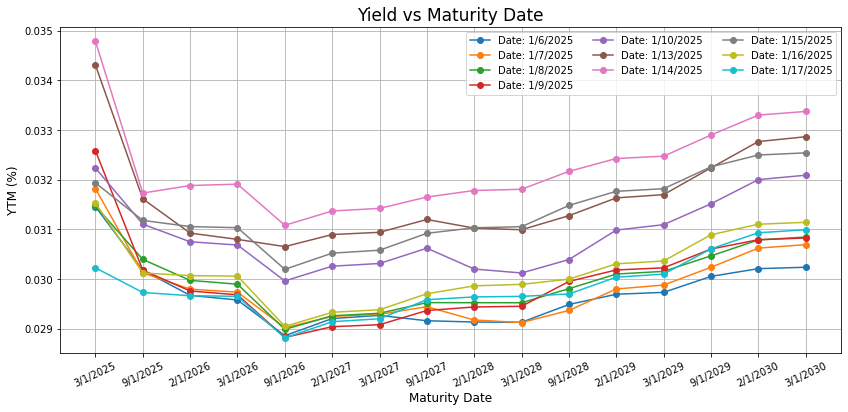

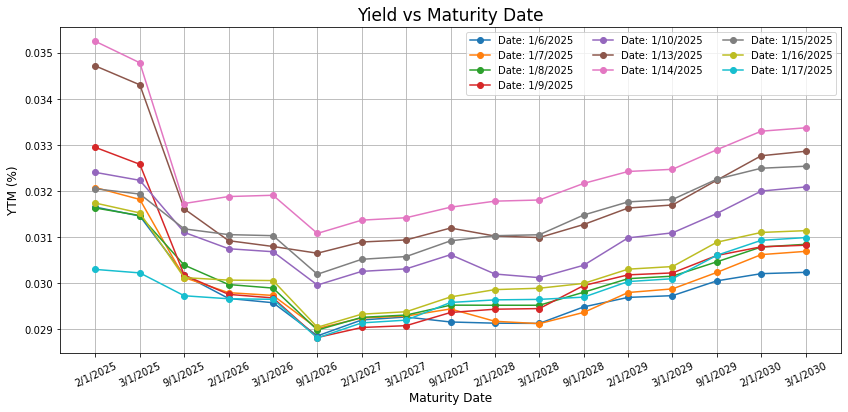

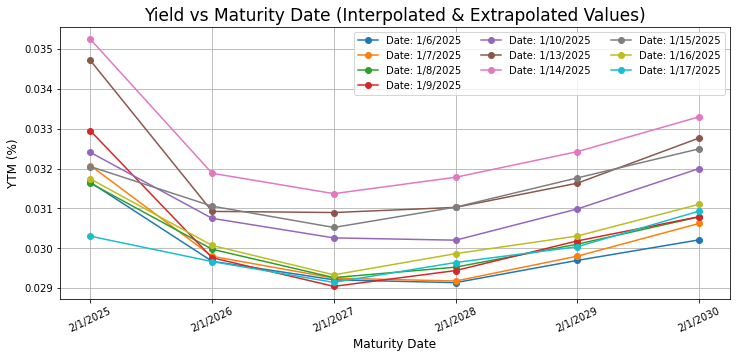

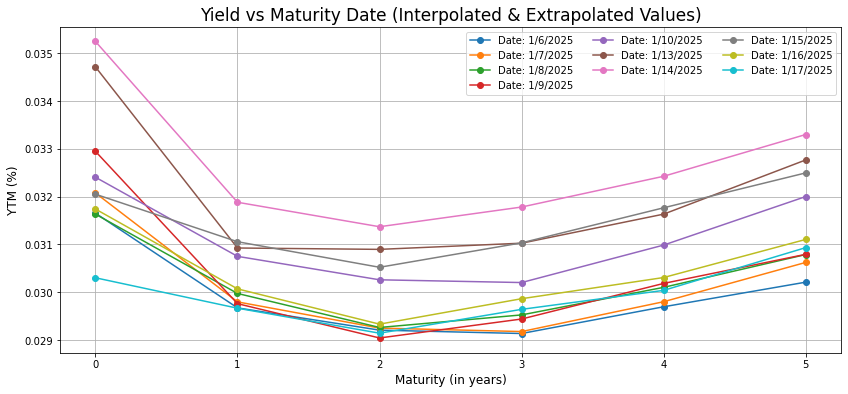

In [6]:
pd_rev = pd_df__3_1_2025.iloc[::-1].reset_index(drop=True).copy()

pd_dates = pd_rev["Date"].tolist()

interp_extrap_list = ["2/1/2025", "2/1/2026", "2/1/2027", "2/1/2028", "2/1/2029", "2/1/2030"] #*#**#*# ASSUME THE CURRENT DATE IS 2/1/2025


plt.figure(figsize=(14, 6))
for i in range(len(ytm_list_ALL_interpolated_BETTER)):

    plt.plot(interpolated_full_dates_list, ytm_list_ALL_interpolated_BETTER[i], 'o-', label=f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date", size = 12)
plt.ylabel("YTM (%)", size = 12)
plt.title("Yield vs Maturity Date", size = 17)
plt.legend(ncol=3)
plt.grid(True)
plt.xticks(rotation=25)
plt.show()


plt.figure(figsize=(14, 6))
for i in range(len(ytm_list_ALL_extrapolated_BETTER)):
    plt.plot(extrapolated_full_dates_list, ytm_list_ALL_extrapolated_BETTER[i], 'o-', label=f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date", size = 12)
plt.ylabel("YTM (%)", size = 12)
plt.title("Yield vs Maturity Date", size = 17)
plt.legend(ncol=3)
plt.grid(True)
plt.xticks(rotation=25)
plt.show()


plt.figure(figsize=(12, 5))  
for i in range(0 , len(ytm_list_ONLY_intandextrap_indexes)):
    plt.plot(interp_extrap_list , ytm_list_ONLY_intandextrap_indexes[i] , 'o-', label = f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date", size = 12)
plt.ylabel("YTM (%)", size = 12)
plt.title("Yield vs Maturity Date (Interpolated & Extrapolated Values)", size = 17)
plt.legend(ncol=3)
plt.grid(True)
plt.xticks(rotation=25)
plt.show()


plt.figure(figsize=(14, 6))  
for i in range(0 , len(ytm_list_ONLY_intandextrap_indexes)):
    plt.plot([0,1,2,3,4,5] , ytm_list_ONLY_intandextrap_indexes[i] , 'o-', label = f"Date: {pd_dates[i]}")

plt.xlabel("Maturity (in years)", size = 12)
plt.ylabel("YTM (%)", size = 12)
plt.title("Yield vs Maturity Date (Interpolated & Extrapolated Values)", size = 17)
plt.legend(ncol=3)
plt.grid(True)
plt.show()






---
## Spot Rate
---

In [7]:




def spot_rate_calculator_BETTER():
        

    payment_period = 365 
    coupon_payment_period_dates = ["3/1/2025", "9/1/2025", "3/1/2026", "9/1/2026", "3/1/2027", "9/1/2027", "3/1/2028", "9/1/2028", "3/1/2029", "9/1/2029", "3/1/2030"]


    t_til_final_pay_list = []
    t_final_minus_1_list = []
    t_final_minus_2_list = []
    t_final_minus_3_list = []
    t_final_minus_4_list = []
    t_final_minus_5_list = []
    t_final_minus_6_list = []
    t_final_minus_7_list = []
    t_final_minus_8_list = []
    t_final_minus_9_list = []
    t_final_minus_10_list = []

    df1 = pd_df__3_1_2025
    df_reverse = df1.iloc[::-1].reset_index(drop=True).copy()

    for i in df_reverse["Date"].tolist():
        t_til_final_pay = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[10], "%m/%d/%Y")).days) / payment_period
        t_til_final_pay_list.append(t_til_final_pay)

        t_final_minus_1 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[9], "%m/%d/%Y")).days) / payment_period
        t_final_minus_1_list.append(t_final_minus_1)
    
        t_final_minus_2 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[8], "%m/%d/%Y")).days) / payment_period
        t_final_minus_2_list.append(t_final_minus_2)

        t_final_minus_3 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[7], "%m/%d/%Y")).days) / payment_period
        t_final_minus_3_list.append(t_final_minus_3)

        t_final_minus_4 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[6], "%m/%d/%Y")).days) / payment_period
        t_final_minus_4_list.append(t_final_minus_4)

        t_final_minus_5 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[5], "%m/%d/%Y")).days) / payment_period
        t_final_minus_5_list.append(t_final_minus_5)

        t_final_minus_6 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[4], "%m/%d/%Y")).days) / payment_period
        t_final_minus_6_list.append(t_final_minus_6)

        t_final_minus_7 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[3], "%m/%d/%Y")).days) / payment_period
        t_final_minus_7_list.append(t_final_minus_7)

        t_final_minus_8 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[2], "%m/%d/%Y")).days) / payment_period  
        t_final_minus_8_list.append(t_final_minus_8)

        t_final_minus_9 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[1], "%m/%d/%Y")).days) / payment_period  
        t_final_minus_9_list.append(t_final_minus_9)

        t_final_minus_10 = abs((datetime.strptime(i, "%m/%d/%Y") - datetime.strptime(coupon_payment_period_dates[0], "%m/%d/%Y")).days) / payment_period  
        t_final_minus_10_list.append(t_final_minus_10)



#*#*#*#*#*#*#*#* 1st Bond 

    df  = pd_df__3_1_2025
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()
    spot_list__3_1_2025 = []

    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i] 
        expr = lambda rate: final_payment / (1 + rate)**t_final_minus_10_list[i] - price
        spot_3_1_2025 = newton(expr, 0.03)
        spot_list__3_1_2025.append(spot_3_1_2025)

    #*#*#*#*#*#*#*#*#*#*#*#* 2nd Bond

    df  = pd_df__9_1_2025
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()
    spot_list__9_1_2025 = []

    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2
        
        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_9_1_2025 = newton(expr, 0.03)
        spot_list__9_1_2025.append(spot_9_1_2025)

    #*#*#*#*#*#*#*#*#*#*#*#* 3rd Bond

        

    df  = pd_df__3_1_2026
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()
    spot_list__3_1_2026 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_3_1_2026 = newton(expr, 0.03)
        spot_list__3_1_2026.append(spot_3_1_2026)

#*#*#*#*#*#*#*#*#*#*#*#* 4th Bond

    df  = pd_df__9_1_2026
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__9_1_2026 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_9_1_2026 = newton(expr, 0.03)
        spot_list__9_1_2026.append(spot_9_1_2026)

#*#*#*#*#*#*#*#*#*#*#*#* 5th Bond

    df  = pd_df__3_1_2027
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__3_1_2027 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_3_1_2027 = newton(expr, 0.03)
        spot_list__3_1_2027.append(spot_3_1_2027)

#*#*#*#*#*#*#*#*#*#*#*#* 6th Bond

    df  = pd_df__9_1_2027
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__9_1_2027 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_5_list[i] + coupon_payment / (1 + spot_list__3_1_2027[i]) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_9_1_2027 = newton(expr, 0.03)
        spot_list__9_1_2027.append(spot_9_1_2027)

#*#*#*#*#*#*#*#*#*#*#*#* 7th Bond

    df  = pd_df__3_1_2028
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__3_1_2028 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_4_list[i] + coupon_payment / (1 + spot_list__9_1_2027[i]) ** t_final_minus_5_list[i] + coupon_payment / (1 + spot_list__3_1_2027[i]) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_3_1_2028 = newton(expr, 0.03)
        spot_list__3_1_2028.append(spot_3_1_2028)

#*#*#*#*#*#*#*#*#*#*#*#* 8th Bond

    df  = pd_df__9_1_2028
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__9_1_2028 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_3_list[i] + coupon_payment / (1 + spot_list__3_1_2028[i]) ** t_final_minus_4_list[i] + coupon_payment / (1 + spot_list__9_1_2027[i]) ** t_final_minus_5_list[i] + coupon_payment / (1 + spot_list__3_1_2027[i]) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_9_1_2028 = newton(expr, 0.03)
        spot_list__9_1_2028.append(spot_9_1_2028)

#*#*#*#*#*#*#*#*#*#*#*#* 9th Bond


    df  = pd_df__3_1_2029
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__3_1_2029 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_2_list[i] + coupon_payment / (1 + spot_list__9_1_2028[i]) ** t_final_minus_3_list[i] + coupon_payment / (1 + spot_list__3_1_2028[i]) ** t_final_minus_4_list[i] + coupon_payment / (1 + spot_list__9_1_2027[i]) ** t_final_minus_5_list[i] + coupon_payment / (1 + spot_list__3_1_2027[i]) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_3_1_2029 = newton(expr, 0.03)
        spot_list__3_1_2029.append(spot_3_1_2029)

#*#*#*#*#*#*#*#*#*#*#*#* 10th Bond

    df  = pd_df__9_1_2029
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__9_1_2029 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_final_minus_1_list[i] + coupon_payment / (1 + spot_list__3_1_2029[i]) ** t_final_minus_2_list[i] + coupon_payment / (1 + spot_list__9_1_2028[i]) ** t_final_minus_3_list[i] + coupon_payment / (1 + spot_list__3_1_2028[i]) ** t_final_minus_4_list[i] + coupon_payment / (1 + spot_list__9_1_2027[i]) ** t_final_minus_5_list[i] + coupon_payment / (1 + spot_list__3_1_2027[i]) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_9_1_2029 = newton(expr, 0.03)
        spot_list__9_1_2029.append(spot_9_1_2029)


#*#*#*#*#*#*#*#*#*#*#*#* 11th Bond

    df  = pd_df__3_1_2030
    df_reverse = df.iloc[::-1].reset_index(drop=True).copy()

    spot_list__3_1_2030 = []
    for i in range(len(df_reverse["Date"].tolist())):

        coupon_percentage = df_reverse["Coupon Rate (%)"][0] / 100
        final_payment = (100 * coupon_percentage/2) + 100
        coupon_payment = 100 * coupon_percentage/2

        price = df_reverse["Dirty Price"][i]
        expr = lambda rate: final_payment / (1 + rate) ** t_til_final_pay_list[i] + coupon_payment / (1 + spot_list__9_1_2029[i]) ** t_final_minus_1_list[i] + coupon_payment / (1 + spot_list__3_1_2029[i]) ** t_final_minus_2_list[i] + coupon_payment / (1 + spot_list__9_1_2028[i]) ** t_final_minus_3_list[i] + coupon_payment / (1 + spot_list__3_1_2028[i]) ** t_final_minus_4_list[i] + coupon_payment / (1 + spot_list__9_1_2027[i]) ** t_final_minus_5_list[i] + coupon_payment / (1 + spot_list__3_1_2027[i]) ** t_final_minus_6_list[i] + coupon_payment / (1 + spot_list__9_1_2026[i]) ** t_final_minus_7_list[i] + coupon_payment / (1 + spot_list__3_1_2026[i]) ** t_final_minus_8_list[i] + coupon_payment / (1 + spot_list__9_1_2025[i]) ** t_final_minus_9_list[i] + coupon_payment / (1 + spot_list__3_1_2025[i]) ** t_final_minus_10_list[i] - price
        spot_3_1_2030 = newton(expr, 0.03)
        spot_list__3_1_2030.append(spot_3_1_2030)


    return [spot_list__3_1_2025, spot_list__9_1_2025, spot_list__3_1_2026, spot_list__9_1_2026, spot_list__3_1_2027, spot_list__9_1_2027, spot_list__3_1_2028, spot_list__9_1_2028, spot_list__3_1_2029, spot_list__9_1_2029, spot_list__3_1_2030]




In [8]:
spot_list_ALL = spot_rate_calculator_BETTER()


spot_list_1_6 = [spot_list_ALL[0][0], spot_list_ALL[1][0], spot_list_ALL[2][0], spot_list_ALL[3][0], spot_list_ALL[4][0], spot_list_ALL[5][0], spot_list_ALL[6][0], spot_list_ALL[7][0], spot_list_ALL[8][0], spot_list_ALL[9][0], spot_list_ALL[10][0]]
spot_list_1_7 = [spot_list_ALL[0][1], spot_list_ALL[1][1], spot_list_ALL[2][1], spot_list_ALL[3][1], spot_list_ALL[4][1], spot_list_ALL[5][1], spot_list_ALL[6][1], spot_list_ALL[7][1], spot_list_ALL[8][1], spot_list_ALL[9][1], spot_list_ALL[10][1]]
spot_list_1_8 = [spot_list_ALL[0][2], spot_list_ALL[1][2], spot_list_ALL[2][2], spot_list_ALL[3][2], spot_list_ALL[4][2], spot_list_ALL[5][2], spot_list_ALL[6][2], spot_list_ALL[7][2], spot_list_ALL[8][2], spot_list_ALL[9][2], spot_list_ALL[10][2]]
spot_list_1_9 = [spot_list_ALL[0][3], spot_list_ALL[1][3], spot_list_ALL[2][3], spot_list_ALL[3][3], spot_list_ALL[4][3], spot_list_ALL[5][3], spot_list_ALL[6][3], spot_list_ALL[7][3], spot_list_ALL[8][3], spot_list_ALL[9][3], spot_list_ALL[10][3]]
spot_list_1_10 = [spot_list_ALL[0][4], spot_list_ALL[1][4], spot_list_ALL[2][4], spot_list_ALL[3][4], spot_list_ALL[4][4], spot_list_ALL[5][4], spot_list_ALL[6][4], spot_list_ALL[7][4], spot_list_ALL[8][4], spot_list_ALL[9][4], spot_list_ALL[10][4]]
spot_list_1_13 = [spot_list_ALL[0][5], spot_list_ALL[1][5], spot_list_ALL[2][5], spot_list_ALL[3][5], spot_list_ALL[4][5], spot_list_ALL[5][5], spot_list_ALL[6][5], spot_list_ALL[7][5], spot_list_ALL[8][5], spot_list_ALL[9][5], spot_list_ALL[10][5]]
spot_list_1_14 = [spot_list_ALL[0][6], spot_list_ALL[1][6], spot_list_ALL[2][6], spot_list_ALL[3][6], spot_list_ALL[4][6], spot_list_ALL[5][6], spot_list_ALL[6][6], spot_list_ALL[7][6], spot_list_ALL[8][6], spot_list_ALL[9][6], spot_list_ALL[10][6]]
spot_list_1_15 = [spot_list_ALL[0][7], spot_list_ALL[1][7], spot_list_ALL[2][7], spot_list_ALL[3][7], spot_list_ALL[4][7], spot_list_ALL[5][7], spot_list_ALL[6][7], spot_list_ALL[7][7], spot_list_ALL[8][7], spot_list_ALL[9][7], spot_list_ALL[10][7]]
spot_list_1_16 = [spot_list_ALL[0][8], spot_list_ALL[1][8], spot_list_ALL[2][8], spot_list_ALL[3][8], spot_list_ALL[4][8], spot_list_ALL[5][8], spot_list_ALL[6][8], spot_list_ALL[7][8], spot_list_ALL[8][8], spot_list_ALL[9][8], spot_list_ALL[10][8]]
spot_list_1_17 = [spot_list_ALL[0][9], spot_list_ALL[1][9], spot_list_ALL[2][9], spot_list_ALL[3][9], spot_list_ALL[4][9], spot_list_ALL[5][9], spot_list_ALL[6][9], spot_list_ALL[7][9], spot_list_ALL[8][9], spot_list_ALL[9][9], spot_list_ALL[10][9]]


spot_ALL = [spot_list_1_6, spot_list_1_7, spot_list_1_8, spot_list_1_9, spot_list_1_10, spot_list_1_13, spot_list_1_14, spot_list_1_15, spot_list_1_16, spot_list_1_17]




In [9]:

#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER INTERPOLATION
interpolated_full_dates_list = [ "3/1/2025", "9/1/2025", "2/1/2026", "3/1/2026", "9/1/2026", "2/1/2027", "3/1/2027", "9/1/2027", "2/1/2028", "3/1/2028", "9/1/2028", "2/1/2029", "3/1/2029", "9/1/2029", "2/1/2030", "3/1/2030"]


matrutiy_dates_int_list = mdates.date2num(pd.to_datetime(maturity_dates_list))

interpolated_full_dates_int_list = mdates.date2num(pd.to_datetime(interpolated_full_dates_list))

spot_list_ALL_interpolated_BETTER = []

for i in spot_ALL:

    scipy_interp = interpolate.interp1d(matrutiy_dates_int_list, i, kind = "linear")

    interpolated_spot = scipy_interp(interpolated_full_dates_int_list)

    spot_list_ALL_interpolated_BETTER.append(interpolated_spot)
    
#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER INTERPOLATION.         

#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER EXTRAPOLATION

extrapolated_full_dates_list = ["2/1/2025", "3/1/2025", "9/1/2025", "2/1/2026", "3/1/2026", "9/1/2026", "2/1/2027", "3/1/2027", "9/1/2027", "2/1/2028", "3/1/2028", "9/1/2028", "2/1/2029", "3/1/2029", "9/1/2029", "2/1/2030", "3/1/2030"]

extrapolated_full_dates_int_list = mdates.date2num(pd.to_datetime(extrapolated_full_dates_list))

spot_list_ALL_extrapolated_BETTER = []

for i in spot_ALL:

    scipy_interp = interpolate.interp1d(matrutiy_dates_int_list, i , fill_value="extrapolate", kind="linear")

    interpolated_spot = scipy_interp(extrapolated_full_dates_int_list)

    spot_list_ALL_extrapolated_BETTER.append(interpolated_spot)

#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# BETTER EXTRAPOLATION.         


#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**# ONLY EXTRAPOLATED VALUES



spot_list_ONLY_intandextrap_indexes = []

for i in spot_list_ALL_extrapolated_BETTER : 

    values = [ i[j] for j in range(0 , len(i) , 3)]

    spot_list_ONLY_intandextrap_indexes.append(values)




#*#*#*#*#**##*#*#*#*#**##*#*#*#*#**##*#*#*#*#**#


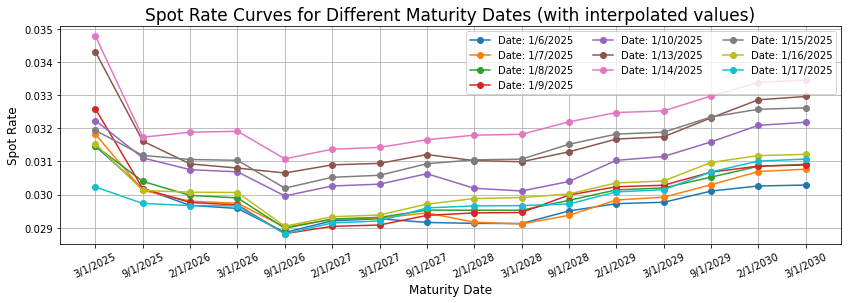

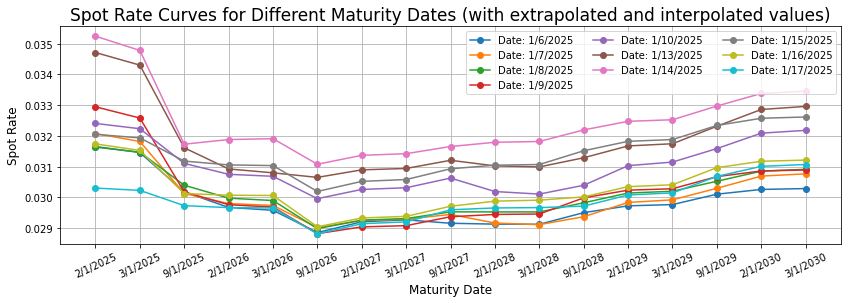

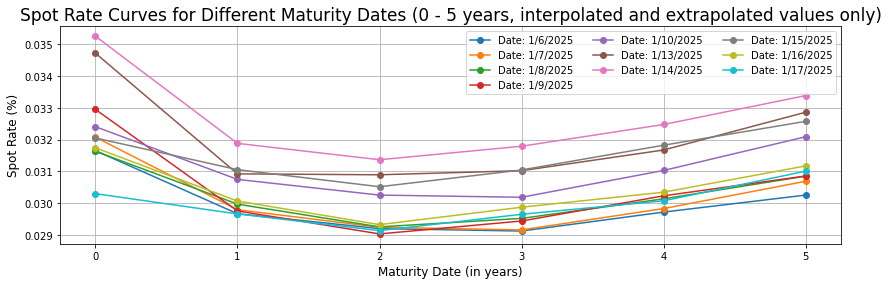

In [10]:
pd_dates = pd_rev["Date"].tolist()

interp_extrap_list = ["2/1/2025", "2/1/2026", "2/1/2027", "2/1/2028", "2/1/2029", "2/1/2030"] #*#**#*# ASSUME THE CURRENT DATE IS 2/1/2025


plt.figure(figsize=(14, 4))
for i in range(len(spot_list_ALL_interpolated_BETTER)):
    plt.plot(interpolated_full_dates_list, spot_list_ALL_interpolated_BETTER[i], 'o-', label=f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date" ,size = 12) 
plt.ylabel("Spot Rate" ,size = 12)
plt.title("Spot Rate Curves for Different Maturity Dates (with interpolated values)", size = 17)
plt.legend(ncol=3, loc = "upper right")
plt.xticks(rotation=25)
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 4))
for i in range(len(spot_list_ALL_extrapolated_BETTER)):
    plt.plot(extrapolated_full_dates_list, spot_list_ALL_extrapolated_BETTER[i], 'o-', label=f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date" ,size = 12)
plt.ylabel("Spot Rate" ,size = 12)
plt.title("Spot Rate Curves for Different Maturity Dates (with extrapolated and interpolated values)", size = 17)
plt.legend(ncol=3, loc = "upper right")
plt.xticks(rotation=25)
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 4))  
for i in range(0, len(spot_list_ONLY_intandextrap_indexes)):
    plt.plot([0, 1, 2, 3, 4, 5], spot_list_ONLY_intandextrap_indexes[i], 'o-', label=f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date (in years)" ,size = 12)
plt.ylabel("Spot Rate (%)", size = 12)
plt.title("Spot Rate Curves for Different Maturity Dates (0 - 5 years, interpolated and extrapolated values only)", size = 17)
plt.legend(ncol=3, loc = "upper right")
plt.grid(True)
plt.show()


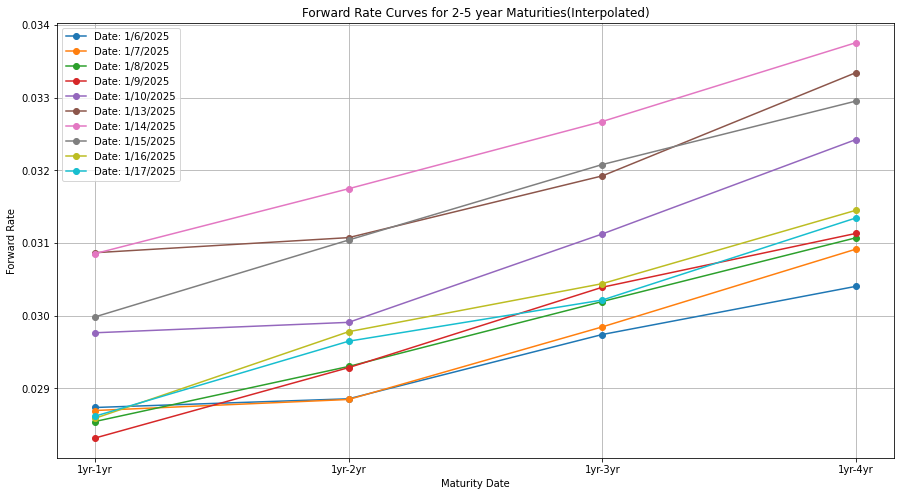

In [11]:
import math



interpolated_dates_list = ["2/1/2026", "2/1/2027", "2/1/2028", "2/1/2029", "2/1/2030"] #*#**#*# ASSUME THE CURRENT DATE IS 2/1/2025



int_extrap_list = ["2/1/2025", "2/1/2026", "2/1/2027", "2/1/2028", "2/1/2029", "2/1/2030"] #*#**#*# ASSUME THE CURRENT DATE IS 2/1/2025


def calculate_forward_rate(S_t, S_tn, t, n):
    numerator = (1 + S_tn)**(2 * (t + n))
    denominator = (1 + S_t)**(2 * t)
    forward_rate = (numerator / denominator)**(1 / (2 * n)) - 1
    return forward_rate

list_ALL_forward_rates = []

for i in spot_list_ONLY_intandextrap_indexes:
    
    list = []
    i = i[1:] #*#*# exclude the extrapolated point

    for j in range(len(i)-1):

        list.append(calculate_forward_rate(i[0], i[j+1], 1, 1+j)) #*#**#*# ASSUME THE CURRENT DATE IS 2/1/2025 so the t = 1
    list_ALL_forward_rates.append(list)


x = interpolated_dates_list[1:]
x2 = ["1yr-1yr", "1yr-2yr", "1yr-3yr", "1yr-4yr"] # 1-1 is from 2/1/2026 to 2/1/2027, 1-2 is from 2/1/2026 to 2/1/2028, 1-3 is from 2/1/2026 to 2/1/2029, 1-4 is from 2/1/2026 to 2/1/2030

plt.figure(figsize=(15, 8))
for i in range(len(list_ALL_forward_rates)):
    plt.plot(x2, list_ALL_forward_rates[i], 'o-', label=f"Date: {pd_dates[i]}")

plt.xlabel("Maturity Date")
plt.ylabel("Forward Rate")
plt.title("Forward Rate Curves for 2-5 year Maturities(Interpolated)")
plt.legend()
plt.grid(True)
plt.show()




## Principal Component Analysis (PCA)


In [12]:
#*#*#**# COVARIANCE MATRICES
import numpy as np

###**#*#*#*#**#*#*#*#**# ytm matrix 
# ytm_list_ALL_interpolated

# X1___2_1_2026 = [ytm_list_ONLY_intandextrap_indexes[0][0], ytm_list_ONLY_intandextrap_indexes[1][0], ytm_list_ONLY_intandextrap_indexes[2][0], ytm_list_ONLY_intandextrap_indexes[3][0], ytm_list_ONLY_intandextrap_indexes[4][0], ytm_list_ONLY_intandextrap_indexes[5][0], ytm_list_ONLY_intandextrap_indexes[6][0], ytm_list_ONLY_intandextrap_indexes[7][0], ytm_list_ONLY_intandextrap_indexes[8][0], ytm_list_ONLY_intandextrap_indexes[9][0]] #*#*# NOTICE --  this are the daily yields from the interpolated calues for the ytm on date 2/1/2026
# X2___2_1_2027 = [ytm_list_ONLY_intandextrap_indexes[0][1], ytm_list_ONLY_intandextrap_indexes[1][1], ytm_list_ONLY_intandextrap_indexes[2][1], ytm_list_ONLY_intandextrap_indexes[3][1], ytm_list_ONLY_intandextrap_indexes[4][1], ytm_list_ONLY_intandextrap_indexes[5][1], ytm_list_ONLY_intandextrap_indexes[6][1], ytm_list_ONLY_intandextrap_indexes[7][1], ytm_list_ONLY_intandextrap_indexes[8][1], ytm_list_ONLY_intandextrap_indexes[9][1]] #*#*# NOTICE --  this are the daily yields from the interpolated calues for the ytm on date 2/1/2027
# X3___2_1_2028 = [ytm_list_ONLY_intandextrap_indexes[0][2], ytm_list_ONLY_intandextrap_indexes[1][2], ytm_list_ONLY_intandextrap_indexes[2][2], ytm_list_ONLY_intandextrap_indexes[3][2], ytm_list_ONLY_intandextrap_indexes[4][2], ytm_list_ONLY_intandextrap_indexes[5][2], ytm_list_ONLY_intandextrap_indexes[6][2], ytm_list_ONLY_intandextrap_indexes[7][2], ytm_list_ONLY_intandextrap_indexes[8][2], ytm_list_ONLY_intandextrap_indexes[9][2]] #*#*# NOTICE --  this are the daily yields from the interpolated calues for the ytm on date 2/1/2028
# X4___2_1_2029 = [ytm_list_ONLY_intandextrap_indexes[0][3], ytm_list_ONLY_intandextrap_indexes[1][3], ytm_list_ONLY_intandextrap_indexes[2][3], ytm_list_ONLY_intandextrap_indexes[3][3], ytm_list_ONLY_intandextrap_indexes[4][3], ytm_list_ONLY_intandextrap_indexes[5][3], ytm_list_ONLY_intandextrap_indexes[6][3], ytm_list_ONLY_intandextrap_indexes[7][3], ytm_list_ONLY_intandextrap_indexes[8][3], ytm_list_ONLY_intandextrap_indexes[9][3]]
# X5___2_1_2030 = [ytm_list_ONLY_intandextrap_indexes[0][4], ytm_list_ONLY_intandextrap_indexes[1][4], ytm_list_ONLY_intandextrap_indexes[2][4], ytm_list_ONLY_intandextrap_indexes[3][4], ytm_list_ONLY_intandextrap_indexes[4][4], ytm_list_ONLY_intandextrap_indexes[5][4], ytm_list_ONLY_intandextrap_indexes[6][4], ytm_list_ONLY_intandextrap_indexes[7][4], ytm_list_ONLY_intandextrap_indexes[8][4], ytm_list_ONLY_intandextrap_indexes[9][4]]



# X1___2_1_2025 = [ytm_list_ONLY_intandextrap_indexes[0][0], ytm_list_ONLY_intandextrap_indexes[1][0], ytm_list_ONLY_intandextrap_indexes[2][0], ytm_list_ONLY_intandextrap_indexes[3][0], ytm_list_ONLY_intandextrap_indexes[4][0], ytm_list_ONLY_intandextrap_indexes[5][0], ytm_list_ONLY_intandextrap_indexes[6][0], ytm_list_ONLY_intandextrap_indexes[7][0], ytm_list_ONLY_intandextrap_indexes[8][0], ytm_list_ONLY_intandextrap_indexes[9][0]] #*#*# NOTICE --  this are the daily yields from the interpolated calues for the ytm on date 2/1/2026
X2___2_1_2026 = [ytm_list_ONLY_intandextrap_indexes[0][1], ytm_list_ONLY_intandextrap_indexes[1][1], ytm_list_ONLY_intandextrap_indexes[2][1], ytm_list_ONLY_intandextrap_indexes[3][1], ytm_list_ONLY_intandextrap_indexes[4][1], ytm_list_ONLY_intandextrap_indexes[5][1], ytm_list_ONLY_intandextrap_indexes[6][1], ytm_list_ONLY_intandextrap_indexes[7][1], ytm_list_ONLY_intandextrap_indexes[8][1], ytm_list_ONLY_intandextrap_indexes[9][1]] #*#*# NOTICE --  this are the daily yields from the interpolated calues for the ytm on date 2/1/2027
X3___2_1_2027 = [ytm_list_ONLY_intandextrap_indexes[0][2], ytm_list_ONLY_intandextrap_indexes[1][2], ytm_list_ONLY_intandextrap_indexes[2][2], ytm_list_ONLY_intandextrap_indexes[3][2], ytm_list_ONLY_intandextrap_indexes[4][2], ytm_list_ONLY_intandextrap_indexes[5][2], ytm_list_ONLY_intandextrap_indexes[6][2], ytm_list_ONLY_intandextrap_indexes[7][2], ytm_list_ONLY_intandextrap_indexes[8][2], ytm_list_ONLY_intandextrap_indexes[9][2]] #*#*# NOTICE --  this are the daily yields from the interpolated calues for the ytm on date 2/1/2028
X4___2_1_2028 = [ytm_list_ONLY_intandextrap_indexes[0][3], ytm_list_ONLY_intandextrap_indexes[1][3], ytm_list_ONLY_intandextrap_indexes[2][3], ytm_list_ONLY_intandextrap_indexes[3][3], ytm_list_ONLY_intandextrap_indexes[4][3], ytm_list_ONLY_intandextrap_indexes[5][3], ytm_list_ONLY_intandextrap_indexes[6][3], ytm_list_ONLY_intandextrap_indexes[7][3], ytm_list_ONLY_intandextrap_indexes[8][3], ytm_list_ONLY_intandextrap_indexes[9][3]]
X5___2_1_2029 = [ytm_list_ONLY_intandextrap_indexes[0][4], ytm_list_ONLY_intandextrap_indexes[1][4], ytm_list_ONLY_intandextrap_indexes[2][4], ytm_list_ONLY_intandextrap_indexes[3][4], ytm_list_ONLY_intandextrap_indexes[4][4], ytm_list_ONLY_intandextrap_indexes[5][4], ytm_list_ONLY_intandextrap_indexes[6][4], ytm_list_ONLY_intandextrap_indexes[7][4], ytm_list_ONLY_intandextrap_indexes[8][4], ytm_list_ONLY_intandextrap_indexes[9][4]]
X6___2_1_2030 = [ytm_list_ONLY_intandextrap_indexes[0][5], ytm_list_ONLY_intandextrap_indexes[1][5], ytm_list_ONLY_intandextrap_indexes[2][5], ytm_list_ONLY_intandextrap_indexes[3][5], ytm_list_ONLY_intandextrap_indexes[4][5], ytm_list_ONLY_intandextrap_indexes[5][5], ytm_list_ONLY_intandextrap_indexes[6][5], ytm_list_ONLY_intandextrap_indexes[7][5], ytm_list_ONLY_intandextrap_indexes[8][5], ytm_list_ONLY_intandextrap_indexes[9][5]]


# X1__log = np.log(np.array(X1___2_1_2025[1:]) / np.array(X1___2_1_2025[0:-1]))
X2__log = np.log(np.array(X2___2_1_2026[1:]) / np.array(X2___2_1_2026[0:-1]))
X3__log = np.log(np.array(X3___2_1_2027[1:]) / np.array(X3___2_1_2027[0:-1]))
X4__log = np.log(np.array(X4___2_1_2028[1:]) / np.array(X4___2_1_2028[0:-1]))
X5__log = np.log(np.array(X5___2_1_2029[1:]) / np.array(X5___2_1_2029[0:-1]))
X6__log = np.log(np.array(X6___2_1_2030[1:]) / np.array(X6___2_1_2030[0:-1]))

#  the log returns into a matrix
X_matrix = np.vstack([ X2__log, X3__log, X4__log, X5__log, X6__log])


covariance_matrix = np.cov(X_matrix)

print("Covariance Matrix:")
print(covariance_matrix)

###**#*#*#*#**#*#*#*#**# forwards matrix 

F1___2_1_2026 = [list_ALL_forward_rates[0][0], list_ALL_forward_rates[1][0], list_ALL_forward_rates[2][0], list_ALL_forward_rates[3][0], list_ALL_forward_rates[4][0], list_ALL_forward_rates[5][0], list_ALL_forward_rates[6][0], list_ALL_forward_rates[7][0], list_ALL_forward_rates[8][0], list_ALL_forward_rates[9][0]]
F2___2_1_2027 = [list_ALL_forward_rates[0][1], list_ALL_forward_rates[1][1], list_ALL_forward_rates[2][1], list_ALL_forward_rates[3][1], list_ALL_forward_rates[4][1], list_ALL_forward_rates[5][1], list_ALL_forward_rates[6][1], list_ALL_forward_rates[7][1], list_ALL_forward_rates[8][1], list_ALL_forward_rates[9][1]]
F3___2_1_2028 = [list_ALL_forward_rates[0][2], list_ALL_forward_rates[1][2], list_ALL_forward_rates[2][2], list_ALL_forward_rates[3][2], list_ALL_forward_rates[4][2], list_ALL_forward_rates[5][2], list_ALL_forward_rates[6][2], list_ALL_forward_rates[7][2], list_ALL_forward_rates[8][2], list_ALL_forward_rates[9][2]]
F4___2_1_2029 = [list_ALL_forward_rates[0][3], list_ALL_forward_rates[1][3], list_ALL_forward_rates[2][3], list_ALL_forward_rates[3][3], list_ALL_forward_rates[4][3], list_ALL_forward_rates[5][3], list_ALL_forward_rates[6][3], list_ALL_forward_rates[7][3], list_ALL_forward_rates[8][3], list_ALL_forward_rates[9][3]]

F1__log = np.log(np.array(F1___2_1_2026[1:]) / np.array(F1___2_1_2026[0:-1]))
F2__log = np.log(np.array(F2___2_1_2027[1:]) / np.array(F2___2_1_2027[0:-1]))
F3__log = np.log(np.array(F3___2_1_2028[1:]) / np.array(F3___2_1_2028[0:-1]))
F4__log = np.log(np.array(F4___2_1_2029[1:]) / np.array(F4___2_1_2029[0:-1]))

#  the log returns into a matrix
F_matrix = np.vstack([F1__log, F2__log, F3__log, F4__log])

#  the covariance matrix
forward_covariance_matrix = np.cov(F_matrix)

print("\nForward Rate Covariance Matrix:")
print(forward_covariance_matrix)

Covariance Matrix:
[[0.00050617 0.00050983 0.00047351 0.00049523 0.00051285]
 [0.00050983 0.00059809 0.00053006 0.00054581 0.00059906]
 [0.00047351 0.00053006 0.00052207 0.00053494 0.00054406]
 [0.00049523 0.00054581 0.00053494 0.00056819 0.0005725 ]
 [0.00051285 0.00059906 0.00054406 0.0005725  0.00062469]]

Forward Rate Covariance Matrix:
[[0.00087447 0.00062304 0.00062591 0.00073755]
 [0.00062304 0.00059698 0.00058984 0.00058307]
 [0.00062591 0.00058984 0.00063149 0.00061935]
 [0.00073755 0.00058307 0.00061935 0.0006954 ]]


In [13]:
#**#*#*#*#*#**# EIGENVALUES AND EIGENVECTORS CALCULATION


#  eigenvalues and eigenvectors for yield covariance matrix
yield_eigenvalues, yield_eigenvectors = np.linalg.eig(covariance_matrix)

print("Yield Covariance Matrix Eigenvalues:")
print(yield_eigenvalues)
print("\nYield Covariance Matrix Eigenvectors:")
print(yield_eigenvectors)

#  eigenvalues and eigenvectors for forward rate covariance matrix 
forward_eigenvalues, forward_eigenvectors = np.linalg.eig(forward_covariance_matrix)

print("\nForward Rate Covariance Matrix Eigenvalues:")
print(forward_eigenvalues)
print("\nForward Rate Covariance Matrix Eigenvectors:")
print(forward_eigenvectors)


Yield Covariance Matrix Eigenvalues:
[2.69705756e-03 3.89954307e-06 1.53779422e-05 5.48738794e-05
 4.80065385e-05]

Yield Covariance Matrix Eigenvectors:
[[-0.41390971  0.11448244 -0.11895273  0.88404633 -0.14101367]
 [-0.46227357 -0.47727791  0.43627406 -0.18795232 -0.57692964]
 [-0.43227294  0.44304842  0.61511949 -0.10077838  0.47782835]
 [-0.45092745 -0.56246912 -0.37438053 -0.09692632  0.57509776]
 [-0.47411648  0.49642336 -0.52629119 -0.40445645 -0.29700164]]

Forward Rate Covariance Matrix Eigenvalues:
[2.60218658e-03 1.45003454e-04 4.18213793e-05 9.32435553e-06]

Forward Rate Covariance Matrix Eigenvectors:
[[ 0.55399174  0.69836727  0.314135    0.32664279]
 [ 0.45912671 -0.4534647   0.63695435 -0.4217364 ]
 [ 0.47314202 -0.53424428 -0.30329876  0.63145035]
 [ 0.50836251  0.14572567 -0.63530955 -0.56277292]]
